# VISUALIZE VALUE FUNCTIONS

In [1]:
%load_ext autoreload
%autoreload 2

import torch 
import random
import numpy as np 
from matplotlib import pyplot as plt
from tqdm import tqdm 
from neuralop.models.fno import FNO
import jax 
import jax.numpy as jnp
from jax import Array
from mpl_toolkits.axes_grid1 import make_axes_locatable
from copy import deepcopy

import sys 
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator")
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators")

from safe_neural_operators.data_collection import load_hjr_solution, load_grid_states, \
    get_dynamics_model_given_disturbance_fn, \
    get_disturbance_function_sincos, get_dynamics_model_given_disturbance_fn
from safe_neural_operators.hjr_dataset import load_full_training_dataset, HJR_SubDataset, HJRDataset
from safe_neural_operators.gp import GPWrapper
from safe_neural_operators.data_collection import get_disturbance_function_sincos

sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project/custom_sim/quad2d")
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project/custom_sim")
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project")

from deepreach.dynamics import dynamics 
from deepreach.dynamics import dynamics_hjr
from deepreach.utils.comparisons import GroundTruthHJSolution

from toy_env import simEnv
from disturbance_controller_utils import randomGoalNominalController, HorizontalVelocityWind
from fly_around import get_gridvalue_function_from_model
from toy_env import step_dynamics


In [2]:
# Load the data 

load_path = "/media/jingpei/DATA/fno_gp_data"
load_index = 20 

loaded_input, loaded_output = load_hjr_solution(
    load_path=load_path,  
    load_index=load_index
)

grid_states = load_grid_states(load_path=load_path, load_index=0)

print("loaded_input shape", loaded_input.shape)
print("loaded_output shape", loaded_output.shape)
print("grid_states shape", grid_states.shape)

loaded_input shape torch.Size([41, 41, 4])
loaded_output shape torch.Size([41, 41, 41, 41])
grid_states shape (41, 41, 41, 41, 4)


 /home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/data_collection.py:106: FutureWarning:You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
 /home/jingpei/Documents/arclab/neura

In [3]:
# Dataset Processor 
data_root_dir = load_path 
samples_for_train = 100 #400 #500
samples_for_test = 50 
datapoints_per_sample = 1000
batch_size = 256 #32
pre_sample_dataset = True 
encode_output = False 
encode_input = True 
encoding = "channel-wise"
full_ordered_dataset = False

dataset = HJRDataset(root_dir=data_root_dir, 
                    samples_for_train=samples_for_train, 
                    samples_for_test=samples_for_test, 
                    datapoints_per_sample=datapoints_per_sample,

                    batch_size=batch_size, 
                    pre_sample_dataset=pre_sample_dataset, 

                    encode_output=encode_output,
                    encode_input=encode_input,
                    encoding=encoding, 
                    full_ordered_dataset=full_ordered_dataset)

data_processor = dataset.data_processor

 /home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/data_collection.py:115: FutureWarning:You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  0%|          | 0/150 [00:00<?, ?it/

In [4]:
# Load the model 
model_dir = "/media/jingpei/DATA/fno_models/safe_neural-7-20-25_500data_revised"
dataset_path = "/media/jingpei/DATA/fno_gp_data_2000"
device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = FNO.from_checkpoint(save_folder=model_dir, save_name="model")
model = model.to(device)

In [5]:
# Grid states to input image using GP function
image_grid = grid_states[:, :, 0, 0, :]
disturbance_grid = loaded_input

print("Image grid: ", image_grid.shape)
print("Disturbance grid: ", disturbance_grid.shape)

flattened_image_grid = image_grid.reshape(-1, image_grid.shape[-1])
flattened_disturbance_grid = disturbance_grid.reshape(-1, disturbance_grid.shape[-1])
reconstructed_image_grid = flattened_image_grid.reshape(image_grid.shape)
reconstructed_disturbance_grid = flattened_disturbance_grid.reshape(disturbance_grid.shape) 

# Debugging: plot the initial x values of the grid states and then the reconstructed image grid
diff = image_grid[:, :, :] - reconstructed_image_grid[:, :, :]
diff_disturbance = disturbance_grid[:, :, :] - reconstructed_disturbance_grid[:, :, :]
print("Sum Abs Diff: ", np.sum(np.abs(diff)))
print("Sum Abs Diff Disturbance: ", torch.sum(torch.abs(diff_disturbance)))

Image grid:  (41, 41, 4)
Disturbance grid:  torch.Size([41, 41, 4])
Sum Abs Diff:  0.0
Sum Abs Diff Disturbance:  tensor(0.)


In [6]:
# Create and train GP Model 
num_init_indices = 1000
random_indices = np.random.choice(flattened_image_grid.shape[0], size=num_init_indices, replace=False)

model_input_indices = [0, 1] # x,y
x_init = flattened_image_grid[random_indices, :][:, model_input_indices]
y_init = flattened_disturbance_grid[random_indices, :][:, 0:1] # Have the disturbance magnitude be one number only
print("x_init shape: ", x_init.shape)
print("y_init shape: ", y_init.shape)

gp_model = GPWrapper(X_init=x_init, Y_init=y_init, optimize=True)
print(gp_model.model)

x_init shape:  (1000, 2)
y_init shape:  torch.Size([1000, 1])

Name : GP regression
Objective : -4171.08584930032
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                   value  |  constraints  |  priors
  rbf.variance             |     0.13810840806599264  |      +ve      |        
  rbf.lengthscale          |      0.3702789051578737  |      +ve      |        
  Gaussian_noise.variance  |  2.3666322233962233e-14  |      +ve      |        


In [7]:
######### Defining Key Functions #########

# Get Image from GP 
def gp_model_to_2dinput_image(gp_regression_model, grid_states): 
    """
    NOTE: not suitable for HJR and NN inputs, but useful for debugging GP and plotting with GP model

    Get the 2D disturbance input image from the GP model: 
    NOTE: GP model is only trained on [x,y] -> disturbance value: doesn't care about xvel, yvel here
    As a result image is disturbance value over the x,y grid only
    """
    # grid_states: [x, y, xvel, yvel, 4] state: [x,y,xvel,yvel]
    model_input_indices = [0, 1]  # x, y

    # Get states corresponding to image grid 
    image_grid = grid_states[:, :, 0, 0, :][:, :, model_input_indices]  # [x, y, 2]
    flattened_image_grid = image_grid.reshape(-1, image_grid.shape[-1])  # Flatten to [N, 2]

    # Get the corresponding outputs 
    flattened_disturbance_grid, flattened_disturbance_grid_var = gp_regression_model.predict(flattened_image_grid)  # [N, 2]

    # Reshape into same grid size 
    reconstructed_disturbance_grid = flattened_disturbance_grid.reshape(image_grid.shape[0], image_grid.shape[1], 1)  # [x, y, 1]
    reconstructed_disturbance_grid_var = flattened_disturbance_grid_var.reshape(image_grid.shape[0], image_grid.shape[1], 1)  # [x, y, 1]   

    # Output as Image
    return reconstructed_disturbance_grid, reconstructed_disturbance_grid_var

# Get Image from GP with proper thresholding for HJR
def gp_model_to_2dinput_image_with_clipping(gp_regression_model, grid_states, vmin, vmax, num_std_away):
    """
    NOTE: this looks certain std away to and clips the image between vmin and vmax - more suitable for HJR and NN inputs

    Get the 2D disturbance input image from the GP model: 
    NOTE: GP model is only trained on [x,y] -> disturbance value: doesn't care about xvel, yvel here
    As a result image is disturbance value over the x,y grid only
    """
    # grid_states: [x, y, xvel, yvel, 4] state: [x,y,xvel,yvel]
    model_input_indices = [0, 1]  # x, y

    # Get states corresponding to image grid 
    image_grid = grid_states[:, :, 0, 0, :][:, :, model_input_indices]  # [x, y, 2]
    flattened_image_grid = image_grid.reshape(-1, image_grid.shape[-1])  # Flatten to [N, 2]

    # Get the corresponding outputs 
    flattened_disturbance_grid, flattened_disturbance_grid_var = gp_regression_model.predict(flattened_image_grid)  # [N, 2]

    # Get std away image
    flattened_disturbance_grid_stdaway = np.array(flattened_disturbance_grid) + num_std_away * np.sqrt(flattened_disturbance_grid_var)
    flattened_disturbance_grid_stdaway = np.clip(flattened_disturbance_grid_stdaway, vmin, vmax)  # Clip to vmin and vmax for visualization

    # Reshape into same grid size 
    reconstructed_disturbance_grid_stdaway = flattened_disturbance_grid_stdaway.reshape(image_grid.shape[0], image_grid.shape[1], 1)  # [x, y, 1]
    reconstructed_disturbance_grid = flattened_disturbance_grid.reshape(image_grid.shape[0], image_grid.shape[1], 1)  # [x, y, 1]
    reconstructed_disturbance_grid_var = flattened_disturbance_grid_var.reshape(image_grid.shape[0], image_grid.shape[1], 1)  # [x, y, 1]   

    # Output as Image
    return reconstructed_disturbance_grid_stdaway, reconstructed_disturbance_grid, reconstructed_disturbance_grid_var

GP predicted disturbance image shape:  (41, 41, 1)
Original disturbance grid shape:  torch.Size([41, 41, 4])
Difference shape:  torch.Size([41, 41])


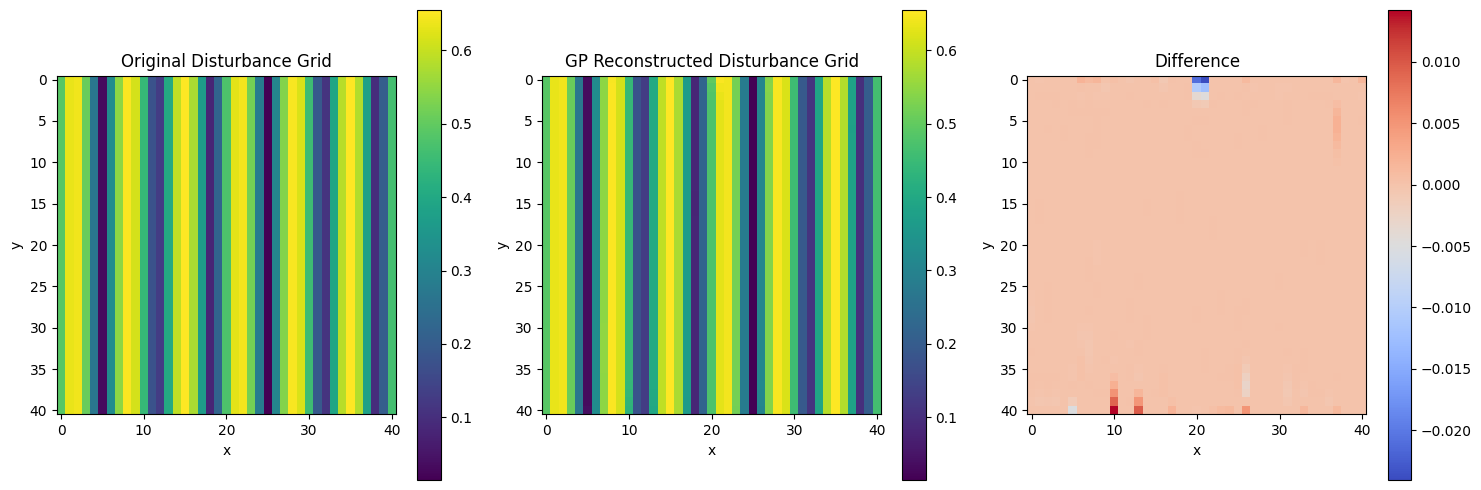

In [8]:
gp_predicted_disturbance_image, gp_predicted_disturbance_var_image  = gp_model_to_2dinput_image(gp_model, grid_states)

# Calculate the difference
difference = disturbance_grid[:, :, 0] - gp_predicted_disturbance_image[:, :, 0]
print("GP predicted disturbance image shape: ", gp_predicted_disturbance_image.shape)
print("Original disturbance grid shape: ", disturbance_grid.shape)
print("Difference shape: ", difference.shape)

# Plot the original disturbance grid, GP reconstructed one, and the difference
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(np.rot90(disturbance_grid[:, :, 0]), cmap='viridis', interpolation='nearest')
axes[0].set_title("Original Disturbance Grid")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
im0 = axes[0].imshow(np.rot90(disturbance_grid[:, :, 0]), cmap='viridis', interpolation='nearest')
fig.colorbar(im0, ax=axes[0])

axes[1].imshow(np.rot90(np.rot90(gp_predicted_disturbance_image[:, :, 0])), cmap='viridis', interpolation='nearest')
axes[1].set_title("GP Reconstructed Disturbance Grid")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
im1 = axes[1].imshow(np.rot90(gp_predicted_disturbance_image[:, :, 0]), cmap='viridis', interpolation='nearest')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.rot90(difference), cmap='coolwarm', interpolation='nearest')
axes[2].set_title("Difference")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [9]:
# Get the Value Function from GP Model
device = "cpu" #"cuda:0"


grid_states_torch = torch.from_numpy(grid_states).to(device).float()
grid_value_function, channel_dim, flattened_tensor_dataset  = get_gridvalue_function_from_model(
    disturbance_input=torch.from_numpy(gp_predicted_disturbance_image[:, :, 0]).to(device).float(), 
    grid_states=np.array(grid_states), 
    model=model.to(device), 
    data_processor=data_processor, 
    device=device)

learned_value_function = grid_value_function


 /home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/fly_around.py:83: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


 /home/jingpei/anaconda3/envs/neuraloperator_deepreach/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning:os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
 /home/jingpei/anaconda3/envs/neuraloperator_deepreach/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning:os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


In [10]:
print("Learned Value Function shape: ", learned_value_function.shape)
print("GT Value Function shape: ", loaded_output.shape)

Learned Value Function shape:  torch.Size([41, 41, 41, 41])
GT Value Function shape:  torch.Size([41, 41, 41, 41])


xvels [-2.         -1.9000001  -1.8        -1.7        -1.5999999  -1.5
 -1.4000001  -1.3        -1.2        -1.0999999  -1.         -0.90000004
 -0.79999995 -0.69999987 -0.59999996 -0.5        -0.40000004 -0.29999995
 -0.19999987 -0.09999996  0.          0.10000014  0.20000005  0.29999995
  0.4000001   0.5         0.60000014  0.70000005  0.79999995  0.9000001
  1.          1.1000001   1.2         1.3         1.4000001   1.5
  1.6000001   1.7         1.8         1.9000001   2.        ]
yvels [-2.         -1.9000001  -1.8        -1.7        -1.5999999  -1.5
 -1.4000001  -1.3        -1.2        -1.0999999  -1.         -0.90000004
 -0.79999995 -0.69999987 -0.59999996 -0.5        -0.40000004 -0.29999995
 -0.19999987 -0.09999996  0.          0.10000014  0.20000005  0.29999995
  0.4000001   0.5         0.60000014  0.70000005  0.79999995  0.9000001
  1.          1.1000001   1.2         1.3         1.4000001   1.5
  1.6000001   1.7         1.8         1.9000001   2.        ]
xvel:  0.0
yvel:  

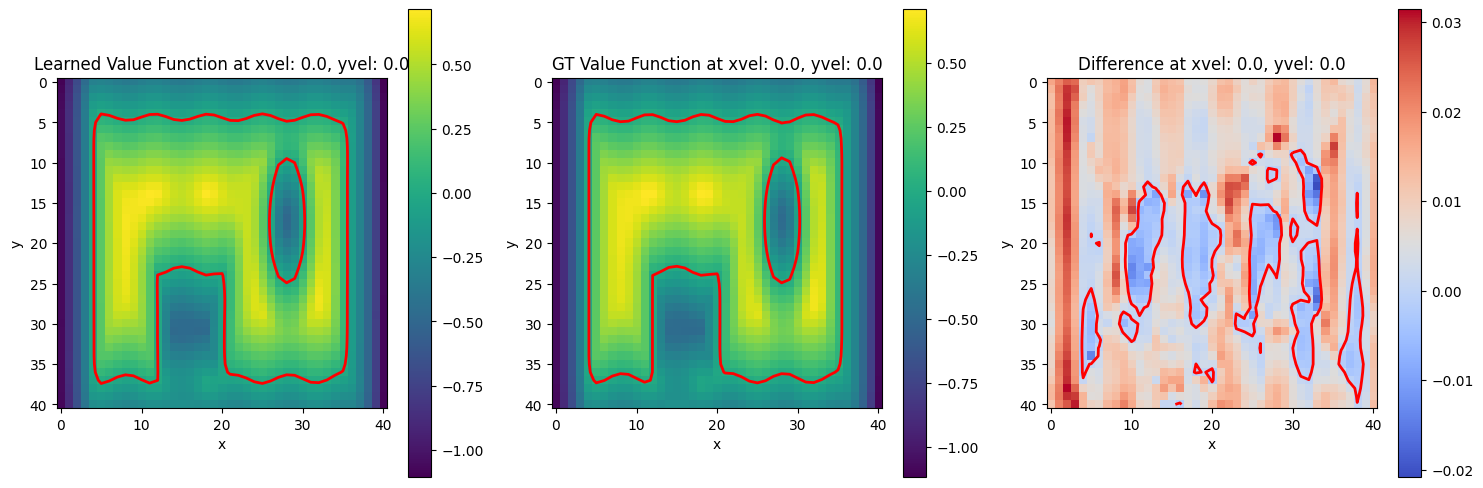

In [11]:
# Visualize Learned Value Function
xvels = grid_states[0, 0, :, 0, 2]
yvels = grid_states[0, 0, 0, :, 3]
print("xvels", xvels)
print("yvels", yvels)

xvel_slice = 20 
yvel_slice = 20
xvel = xvels[xvel_slice]
yvel = yvels[yvel_slice]
print("xvel: ", xvel)
print("yvel: ", yvel)

curr_value_function = learned_value_function[:, :, xvel_slice, yvel_slice]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Learned Value Function
axes[0].imshow(np.rot90(curr_value_function), cmap='viridis', interpolation='nearest')
axes[0].contour(np.rot90(curr_value_function), levels=[0], colors='red', linewidths=2)
axes[0].set_title(f"Learned Value Function at xvel: {xvel}, yvel: {yvel}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
im0 = axes[0].imshow(np.rot90(curr_value_function), cmap='viridis', interpolation='nearest')
fig.colorbar(im0, ax=axes[0])

# Plot Ground Truth Value Function
gt_value_function = loaded_output[:, :, xvel_slice, yvel_slice]
axes[1].imshow(np.rot90(gt_value_function), cmap='viridis', interpolation='nearest')
axes[1].contour(np.rot90(gt_value_function), levels=[0], colors='red', linewidths=2)
axes[1].set_title(f"GT Value Function at xvel: {xvel}, yvel: {yvel}")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
im1 = axes[1].imshow(np.rot90(gt_value_function), cmap='viridis', interpolation='nearest')
fig.colorbar(im1, ax=axes[1])

# Plot Difference
difference = curr_value_function - gt_value_function
axes[2].imshow(np.rot90(difference), cmap='coolwarm', interpolation='nearest')
axes[2].contour(np.rot90(difference), levels=[0], colors='red', linewidths=2)
axes[2].set_title(f"Difference at xvel: {xvel}, yvel: {yvel}")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
im2 = axes[2].imshow(np.rot90(difference), cmap='coolwarm', interpolation='nearest')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [12]:
######## Defining Key Functions ########

def plot_value_functions_comparison(learned_value_function, gt_value_function, xvel_slices = [20, 15, 10, 5, 0], yvel_slices=[20]):
    for yvel_slice in yvel_slices: 
        # Visualize True Value Function
        fig, axes = plt.subplots(3, len(xvel_slices), figsize=(20, 15))

        for i, xvel_slice in enumerate(xvel_slices):
            xvel = xvels[xvel_slice]
            yvel = yvels[yvel_slice]

            # Learned Value Function
            curr_value_function = learned_value_function[:, :, xvel_slice, yvel_slice]
            im0 = axes[0, i].imshow(np.rot90(curr_value_function), cmap='viridis', interpolation='nearest')
            axes[0, i].contour(np.rot90(curr_value_function), levels=[0], colors='red', linewidths=2)
            axes[0, i].set_title(f"Learned Value Function\nxvel: {xvel}, yvel: {yvel}")
            axes[0, i].set_xlabel("x")
            axes[0, i].set_ylabel("y")
            divider0 = make_axes_locatable(axes[0, i])
            cax0 = divider0.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im0, cax=cax0)

            # Ground Truth Value Function
            # gt_value_function = loaded_output[:, :, xvel_slice, yvel_slice]
            gt_value_function_slice = gt_value_function[:, :, xvel_slice, yvel_slice]
            im1 = axes[1, i].imshow(np.rot90(gt_value_function_slice), cmap='viridis', interpolation='nearest')
            axes[1, i].contour(np.rot90(gt_value_function_slice), levels=[0], colors='red', linewidths=2)
            axes[1, i].set_title(f"GT Value Function\nxvel: {xvel}, yvel: {yvel}")
            axes[1, i].set_xlabel("x")
            axes[1, i].set_ylabel("y")
            divider1 = make_axes_locatable(axes[1, i])
            cax1 = divider1.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im1, cax=cax1)

            # Difference
            difference = curr_value_function - gt_value_function_slice
            im2 = axes[2, i].imshow(np.rot90(difference), cmap='coolwarm', interpolation='nearest')
            axes[2, i].contour(np.rot90(difference), levels=[0], colors='red', linewidths=2)
            axes[2, i].set_title(f"Difference\nxvel: {xvel}, yvel: {yvel}")
            axes[2, i].set_xlabel("x")
            axes[2, i].set_ylabel("y")
            divider2 = make_axes_locatable(axes[2, i])
            cax2 = divider2.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im2, cax=cax2)

        plt.tight_layout()
        plt.show()

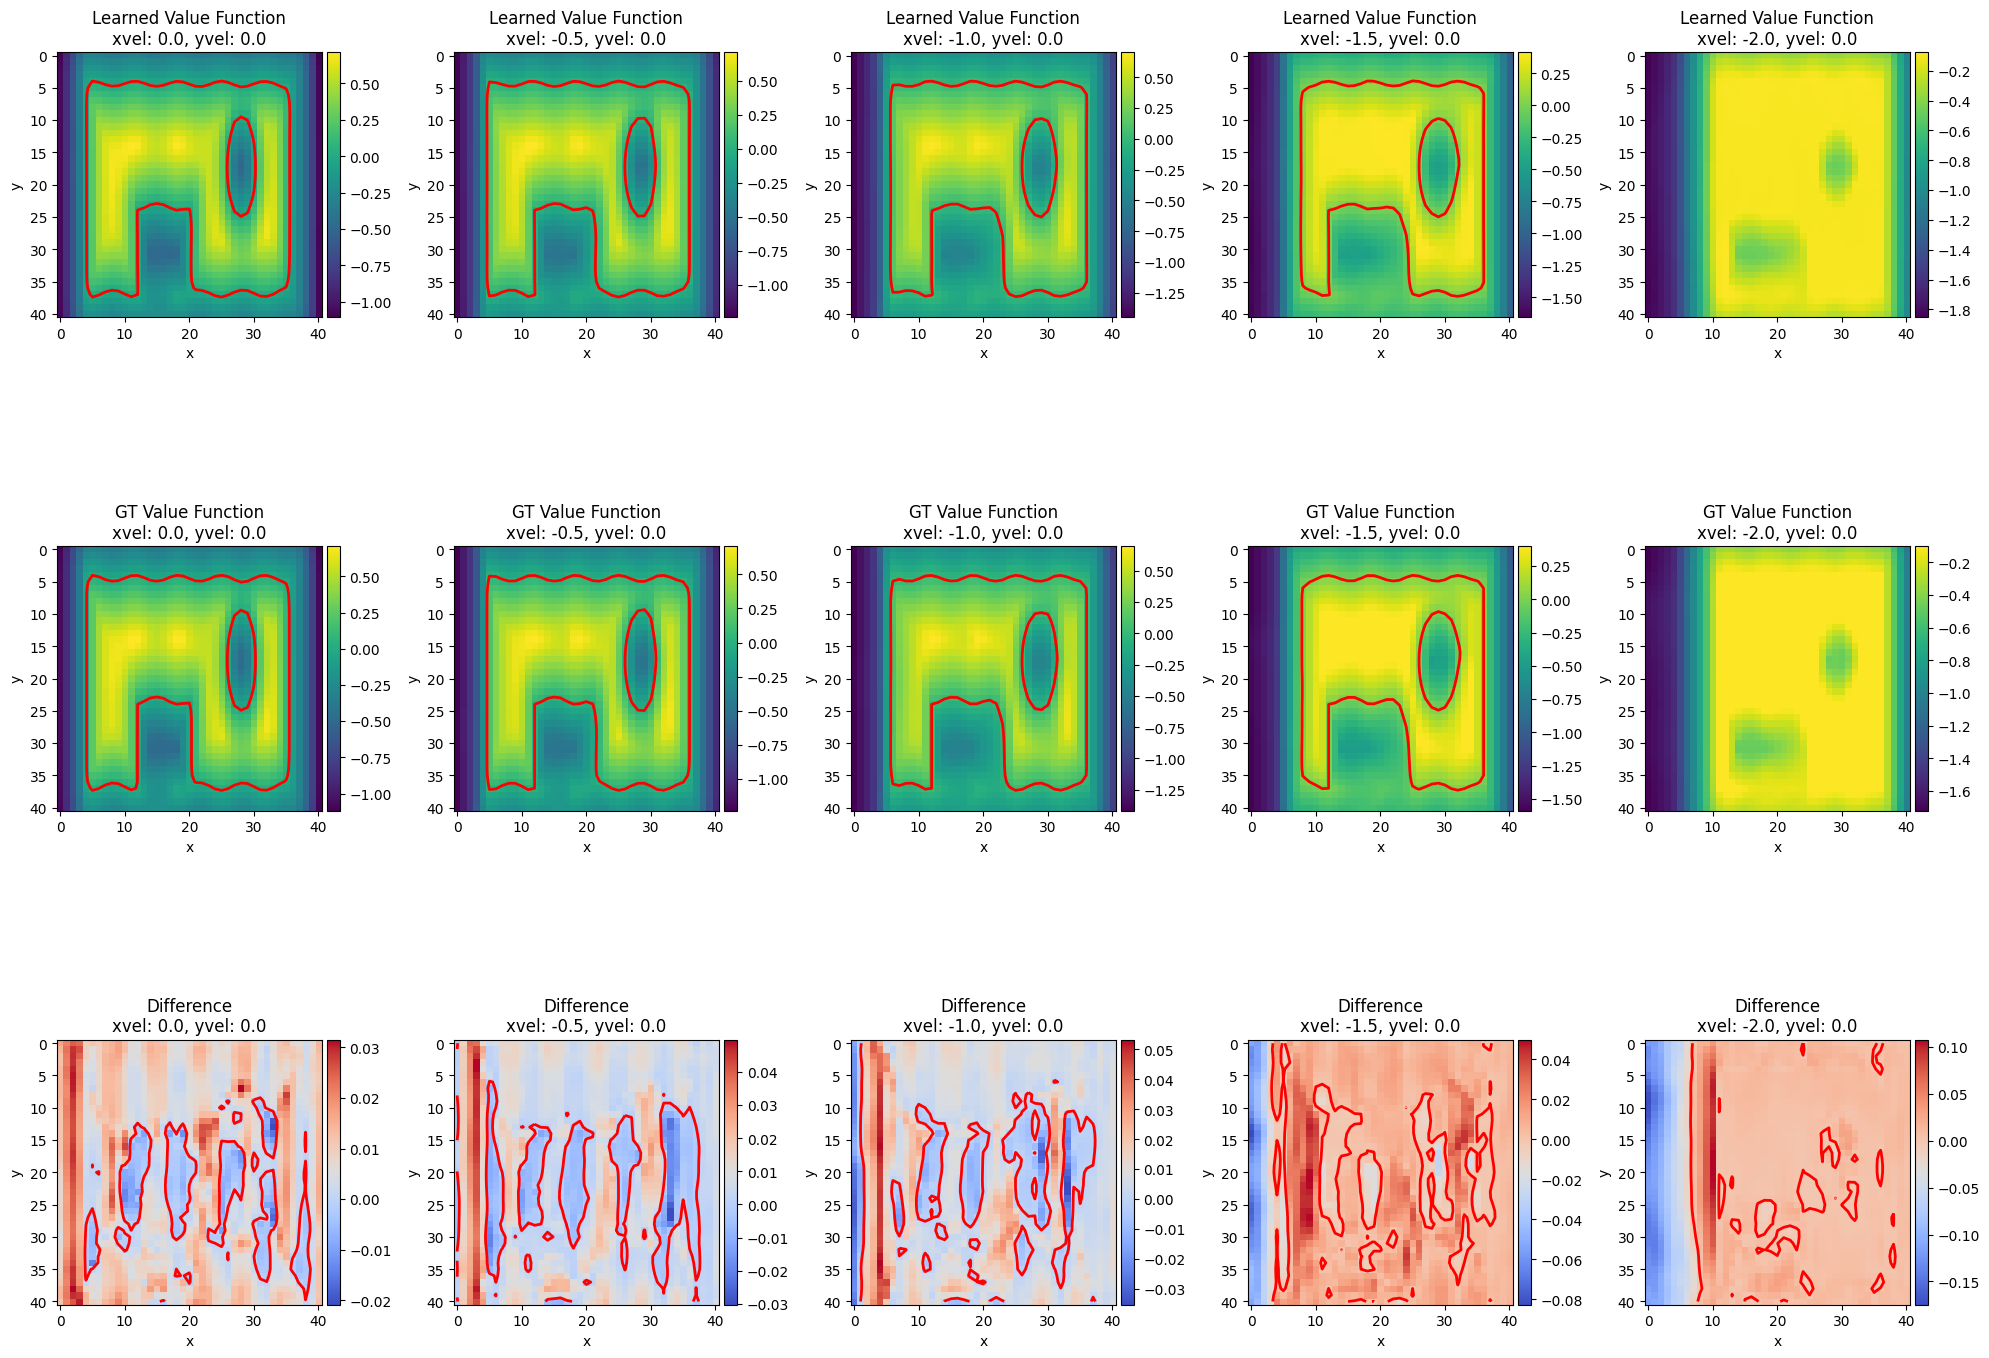

In [13]:
plot_value_functions_comparison(learned_value_function, gt_value_function=loaded_output, xvel_slices = [20, 15, 10, 5, 0], yvel_slices=[20])

In [14]:
######### Defining Key Functions #########

# GP to disturbance function wrapper 
def get_disturbance_fn_from_GP(gp_model, min_disturbance_magnitude, max_disturbance_magnitude, num_std_away=2.0): 
    """
    Wrapper to convert a GP model to a disturbance function that can be used in the dynamics model.
    
    gp outputs: (bath_size, 4) where the last dimension is the max disturbance magnitude on [x, y, xvel, yvel] dimensions
    """
    # NOTE: start with naive implementation - looks one standard deviation away 
    def disturbance_function(state):
        # State: [x, y, xvel, yvel]
        # GP Model: expects only [x,y] states

        # PyTorch branch
        is_torch_tensor = False
        if isinstance(state, (torch.Tensor, np.ndarray)):
            if isinstance(state, torch.Tensor):
                is_torch_tensor = True
                if len(state.shape) == 1:
                    state = state.unsqueeze(0)
                state = state.cpu().numpy() 
            elif isinstance(state, np.ndarray):
                if len(state.shape) == 1:
                    state = np.expand_dims(state, axis=0)    
                state = np.array(state, dtype=np.float32)

            disturbances_mean, disturbances_var = gp_model.predict(state[:, :2])
            disturbances = np.abs(disturbances_mean) + num_std_away * np.sqrt(disturbances_var)  # Get max disturbance magnitude
            # disturbances = np.maximum(np.abs(disturbances_mean + disturbances_var), 
            #               np.abs(disturbances_mean - disturbances_var))  # Get max disturbance magnitude
            disturbances = np.clip(disturbances, min_disturbance_magnitude, max_disturbance_magnitude)
            disturbances = np.tile(disturbances, (1, 4))  # Repeat the disturbance for all 4 dimensions


        # JAX branch
        elif isinstance(state, (jnp.ndarray, Array)):
            if len(state.shape) == 1:
                state = jnp.expand_dims(state, 0)

            # NOTE: for some reason just having thiss is causing some issues, still needs to be debugged!
            
            # print("\n\n\n\n die \n\n\n\n")
            # assert(False)
            
            disturbances_mean, disturbances_var = gp_model.predict_jax(state[:, :2])
            # print("disturbances mean: ", disturbances_mean)
            # print("disturbances var: ", disturbances_var)
            disturbances = jnp.abs(disturbances_mean) + num_std_away * jnp.sqrt(disturbances_var)  # Get max disturbance magnitude
            disturbances = jnp.clip(disturbances, min_disturbance_magnitude, max_disturbance_magnitude)
            disturbances = jnp.tile(disturbances, (1, 4))  # Repeat the disturbance for all 4 dimensions

        else:
            raise TypeError(f"Unsupported input type: {type(state)}")

        
        # disturbances_mean, disturbances_var = gp_model.predict(state[:, :2])
        # disturbances = np.abs(disturbances_mean) + num_std_away * np.sqrt(disturbances_var)  # Get max disturbance magnitude
        # # disturbances = np.maximum(np.abs(disturbances_mean + disturbances_var), 
        # #               np.abs(disturbances_mean - disturbances_var))  # Get max disturbance magnitude
        # disturbances = np.clip(disturbances, min_disturbance_magnitude, max_disturbance_magnitude)
        # disturbances = np.tile(disturbances, (1, 4))  # Repeat the disturbance for all 4 dimensions


        if is_torch_tensor:
            # print("Converting disturbances to torch tensor")
            disturbances = torch.tensor(disturbances)
        else:
            # print("Converting disturbances to jax array")
            disturbances = jax.numpy.array(disturbances)
            
        if disturbances.shape[0] == 1: 
            return disturbances[0]
        else:
            return disturbances

    return disturbance_function


from jax import vmap

from jax import vmap
from jax import lax

def get_disturbance_fn_from_GP_jax_USEGRID(gp_model, grid_states, min_disturbance_magnitude, max_disturbance_magnitude, num_std_away=2.0):
    """
    Wrapper to convert a GP model to a disturbance function that can be used in the dynamics model. 
    NOTE: This is a grid based method where you are just finding the closest grid point to the inputted grid state
    and returning that value as the disturbance
    NOTE: preference to get the gp function above working instead. 

    args: 
        - gp_model: GP model that has been trained on [x, y] -> disturbance value
        - grid_states: [x, y, xvel, yvel, 4] grid states that the GP model has been trained on
            NOTE: only have 2d grid states [x, y] for the GP model as that is all you are comparing
        - min_disturbance_magnitude: minimum disturbance magnitude to clip to
        - max_disturbance_magnitude: maximum disturbance magnitude to clip to
        - num_std_away: number of standard deviations away from the mean to consider for the disturbance magnitude
    """

    # Evaluate GP model on grid states 
    flattened_grid_states = grid_states.reshape(-1, grid_states.shape[-1])  # Flatten to [N, 4]
    disturbances_mean, disturbances_var = gp_model.predict(flattened_grid_states[:, :2])
    disturbances_stdaway = np.abs(disturbances_mean) + num_std_away * np.sqrt(disturbances_var)  # Get max disturbance magnitude
    disturbances_stdaway = np.clip(disturbances_stdaway, min_disturbance_magnitude, max_disturbance_magnitude)
    
    flattened_grid_states_jax = jax.numpy.array(flattened_grid_states)  # Convert to JAX array for JAX compatibility
    disturbances_stdaway_jax = jax.numpy.array(disturbances_stdaway)  # Convert to JAX array for JAX compatibility
    grid_xy = jnp.asarray(flattened_grid_states[:, :2])  # [N, 2]
    def compute_single_disturbance_jax(state_xy):
        # state_xy: [2]
        dists = jnp.linalg.norm(grid_xy - state_xy, axis=-1)  # shape: [N]
        idx = jnp.argmin(dists)
        mag = disturbances_stdaway_jax[idx]  # [D]
        return jnp.tile(mag, (4,))  # shape [4] (repeats per dim)

    # Create disturbance function using grid states and evaluted GP model
    def disturbance_function_jax_grid(state):
        # PyTorch branch
        if isinstance(state, torch.Tensor):
            if len(state.shape) == 1:
                state = state.unsqueeze(0)

            distances = torch.norm(torch.tensor(flattened_grid_states[:, :2]).unsqueeze(1) - torch.tensor(state[:, :2]), dim=-1)
            closest_grid_indices = torch.argmin(distances, dim=1)
            mag = torch.tensor(disturbances_stdaway)[closest_grid_indices]

            disturbances = mag.repeat(1, 4).unsqueeze(-1)[:, :, 0]  # shape (B, 4)

        elif isinstance(state, np.ndarray):
            if len(state.shape) == 1:
                state = np.expand_dims(state, axis=0)

            distances = np.linalg.norm(flattened_grid_states[:, None, :2] - state[:, :2], axis=-1)
            closest_grid_indices = np.argmin(distances, axis=0)
            mag = disturbances_stdaway[closest_grid_indices]

            disturbances = np.repeat(mag[:, None], 4, axis=1)[:, :, 0]  # shape (B, 4)

        # JAX branch
        elif isinstance(state, (jnp.ndarray, Array)):
            if len(state.shape) == 1:
                state = jnp.expand_dims(state, 0)
            
            state_xy = state[:, :2]  # shape: [B, 2]

            # jax lax scan implementation
            # state_xy_flat = state.reshape(-1, state.shape[-1])[:, :2]  # [B, 2]
            # def scan_fn(carry, s):
            #     return carry, compute_single_disturbance_jax(s)
            # _, disturbances_flat = lax.scan(scan_fn, None, state_xy_flat)
            # disturbances = disturbances_flat.reshape(state.shape[:-1] + (4,))  # Restore original shape
            # return disturbances[0] if disturbances.shape[0] == 1 else disturbances

            # jax vmap implementation 
            batched_compute = vmap(compute_single_disturbance_jax)
            disturbances = batched_compute(state_xy)  # shape: [B, 4]

            # jax matrix implementation - needs fixing
            # dists = jnp.linalg.norm(flattened_grid_states_jax[:, None, :2] - state_xy[:, :2], axis=-1)  # Compute distances
            # closest_grid_indices = jnp.argmin(dists, axis=0)  # Find closest grid indices
            # mag = disturbances_stdaway_jax[closest_grid_indices]  # Get disturbance magnitudes
            # disturbances = jnp.repeat(mag[:, None], 4, axis=1)  # Repeat magnitudes for all dimensions

            # disturbances = jnp.repeat(mag[:, None], 4, axis=1)[:, :, 0]  # shape (B, 4)

        else:
            raise TypeError(f"Unsupported input type: {type(state)}")

        if disturbances.shape[0] == 1: 
            return disturbances[0]
        else:
            return disturbances
    
    return disturbance_function_jax_grid


### Partial Train over the GP Space

In [15]:
######### Defining Key Functions #########

# Plotting function for GP predicted disturbance image 
def plot_gp_predicted_disturbance_image(gt_disturbance_grid, gp_predicted_disturbance_image, gp_predicted_disturbance_var_image, 
                                        diff_threshold, var_threshold, num_std_away=2.0):
    """
    Plots: 
    1. GP Predicted Disturbance image 
    2. GT Disturbance image
    3. Difference between GP predicted and GT disturbance images
    4. Threshold-masked difference
    5. GP Predicted Disturbance Variance image 
    6. Variance thresholded masked difference
    7. GP Predicted Disturbance + num_std_away std away image
    8. Std away difference image 
    9. Masked Std Away Difference: std away - GT Disturbance image
    """
    if isinstance(gt_disturbance_grid, torch.Tensor):
        gt_disturbance_grid = gt_disturbance_grid.cpu().numpy()
    if isinstance(gp_predicted_disturbance_image, torch.Tensor):
        gp_predicted_disturbance_image = gp_predicted_disturbance_image.cpu().numpy()

    fig, axes = plt.subplots(3, 3, figsize=(25, 15))
    vmin = 0.0 
    vmax = 1.0 

    # Get Difference 
    difference = gp_predicted_disturbance_image - gt_disturbance_grid 

    # Get difference thresholded image 
    difference_thresh_masked = np.abs(deepcopy(difference))
    difference_thresh_masked[np.abs(difference) < diff_threshold] = 0
    difference_thresh_masked[np.abs(difference) >= diff_threshold] = 1
    
    # Get variance thresholded difference image 
    var_forced_value = 1000.0
    var_masked_difference = deepcopy(gp_predicted_disturbance_var_image)
    var_masked_difference[np.abs(gp_predicted_disturbance_var_image) > var_threshold] = var_forced_value

    # Get std away image
    std_away = np.abs(gp_predicted_disturbance_image) + num_std_away * np.sqrt(gp_predicted_disturbance_var_image)

    # Get std away difference image 
    std_away_difference = std_away - gt_disturbance_grid
    std_away_difference_masked = np.abs(deepcopy(std_away_difference))
    std_away_difference_masked[np.abs(std_away_difference) >= diff_threshold] = 1

    # Plotting the images 
    # GP Predicted Disturbance image
    im0 = axes[0, 0].imshow(np.rot90(gp_predicted_disturbance_image[:, :, 0]), cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
    axes[0, 0].set_title("GP Predicted Disturbance")
    divider0 = make_axes_locatable(axes[0, 0])
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im0, cax=cax0)

    # GT Disturbance image
    im1 = axes[0, 1].imshow(np.rot90(gt_disturbance_grid[:, :, 0]), cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
    axes[0, 1].set_title("GT Disturbance")
    divider1 = make_axes_locatable(axes[0, 1])
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax=cax1)

    # Difference between GP predicted and GT disturbance images
    im2 = axes[0, 2].imshow(np.rot90(difference[:, :, 0]), cmap='coolwarm', interpolation='nearest')
    axes[0, 2].set_title("Difference")
    divider2 = make_axes_locatable(axes[0, 2])
    cax2 = divider2.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax=cax2)

    # Threshold-masked difference
    im3 = axes[1, 0].imshow(np.rot90(difference_thresh_masked[:, :, 0]), cmap='binary', interpolation='nearest')
    axes[1, 0].set_title("Threshold-Masked Difference: forced 0 or 1")
    divider3 = make_axes_locatable(axes[1, 0])
    cax3 = divider3.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im3, cax=cax3)

    # GP Predicted Disturbance Variance image
    im4 = axes[1, 1].imshow(np.rot90(gp_predicted_disturbance_var_image[:, :, 0]), cmap='viridis', interpolation='nearest')
    axes[1, 1].set_title("GP Predicted Disturbance Variance")
    divider4 = make_axes_locatable(axes[1, 1])
    cax4 = divider4.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im4, cax=cax4)

    # Variance thresholded masked difference
    im5 = axes[1, 2].imshow(np.rot90(var_masked_difference[:, :, 0]), cmap='binary', interpolation='nearest')
    axes[1, 2].set_title(f"Variance Thresholded Masked Difference: high var = {var_forced_value}")
    divider5 = make_axes_locatable(axes[1, 2])
    cax5 = divider5.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im5, cax=cax5)

    im6 = axes[2, 0].imshow(np.rot90(std_away[:, :, 0]), cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
    axes[2, 0].set_title(f"GP Predicted Disturbance + {num_std_away} std away")
    divider6 = make_axes_locatable(axes[2, 0])
    cax6 = divider6.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im6, cax=cax6)

    im7 = axes[2, 1].imshow(np.rot90(std_away_difference[:, :, 0]), cmap='coolwarm', interpolation='nearest', vmin=vmin, vmax=vmax)
    axes[2, 1].set_title(f"Std Away Difference: std away - GT Disturbance")
    divider7 = make_axes_locatable(axes[2, 1])
    cax7 = divider7.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im7, cax=cax7)


    im8 = axes[2, 2].imshow(np.rot90(std_away_difference_masked[:, :, 0]), cmap='viridis', interpolation='nearest')
    axes[2, 2].set_title(f"Masked Std Away Difference: std away - GT Disturbance: thresh {diff_threshold}")
    divider8 = make_axes_locatable(axes[2, 2])
    cax8 = divider8.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im8, cax=cax8)
    
    # Hide unused subplots
    for ax in axes.flat:
        if not ax.has_data():
            ax.set_visible(False)

    plt.tight_layout()
    plt.show()

Number of close indices:  169


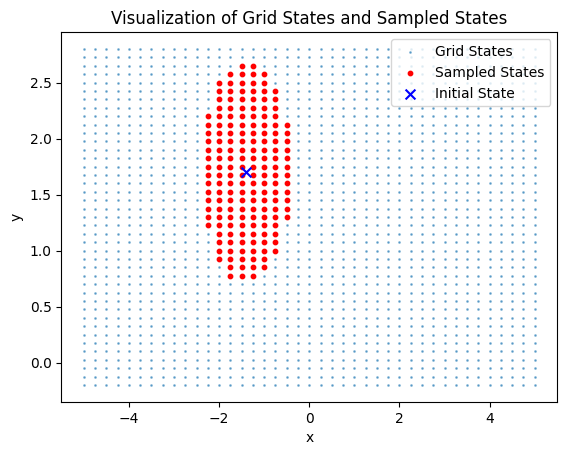


Name : GP regression
Objective : -992.4098809693548
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                   value  |  constraints  |  priors
  rbf.variance             |       39.81531562580147  |      +ve      |        
  rbf.lengthscale          |      0.8179524851580765  |      +ve      |        
  Gaussian_noise.variance  |  6.002937494352208e-256  |      +ve      |        


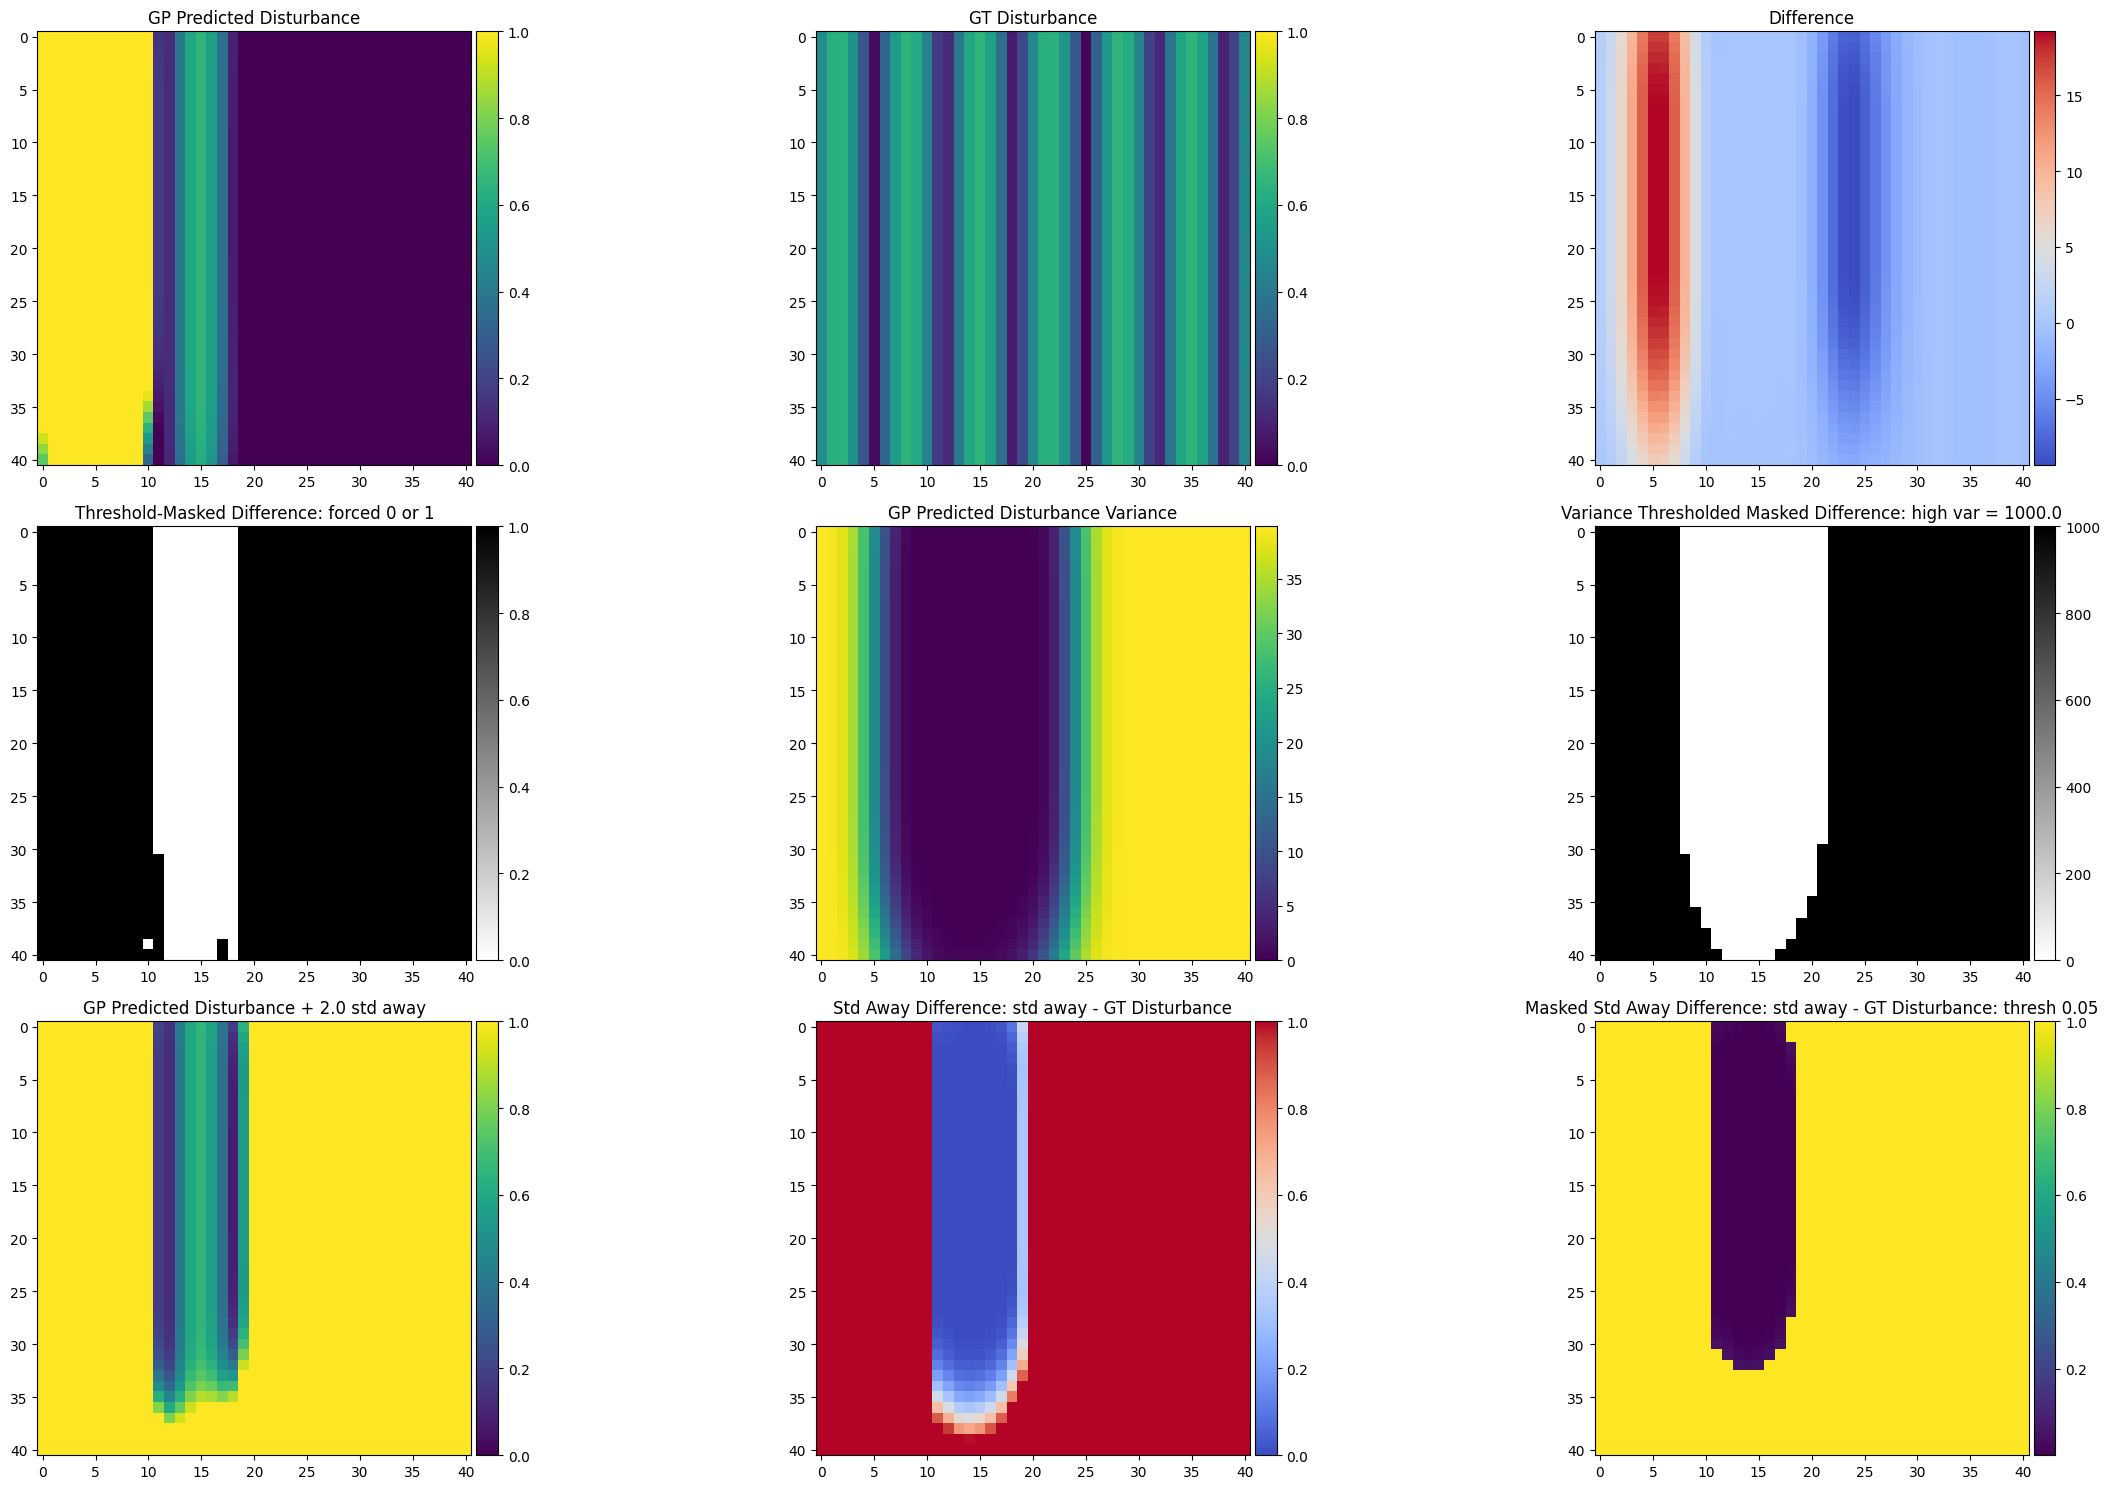

In [16]:
# Partial Train GP over space

init_state=torch.tensor([-1.4, 1.7, 0.0, 0.0])
sample_radius = 1.0
reoptimize_after_trajectory = True

# Have training data related to some initialization set region 
img_grid_states = grid_states[:, :, 0, 0, :]  # [x, y, xvel, yvel]
flattened_img_grid_states = img_grid_states.reshape(-1, img_grid_states.shape[-1])  # Flatten to [N, 4]
flattened_disturbance_grid = disturbance_grid.reshape(-1, disturbance_grid.shape[-1])

# Get the states close to the initial state
init_state = init_state[:2]  # Only consider x, y for the grid states
distances = np.linalg.norm(flattened_img_grid_states[:, :2] - init_state.cpu().numpy(), axis=1)
close_indices = np.where(distances < sample_radius)[0]
un_close_indices = np.where(distances >= sample_radius)[0]
print("Number of close indices: ", len(close_indices))

# Visualize the grid of image states and the sampled states within it using the grid states
fig, ax = plt.subplots()
ax.scatter(flattened_img_grid_states[:, 0], flattened_img_grid_states[:, 1], s=1, label="Grid States", alpha=0.5)
sampled_states = flattened_img_grid_states[close_indices]
ax.scatter(sampled_states[:, 0], sampled_states[:, 1], s=10, color='red', label="Sampled States")
ax.scatter(init_state[0].item(), init_state[1].item(), s=50, color='blue', label="Initial State", marker='x')
ax.set_title("Visualization of Grid States and Sampled States")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

# Train GP model - NOTE: might want to set kernel parameters first 
partial_x_init = flattened_img_grid_states[close_indices, :][:, model_input_indices]  # x, y
partial_y_init = flattened_disturbance_grid[close_indices, :][:, 0:1]  # Disturbance value
gp_model_partial = GPWrapper(X_init=partial_x_init, Y_init=partial_y_init, optimize=True)
print(gp_model_partial.model)

# Get Image from GP
gp_predicted_disturbance_image_partial, gp_predicted_disturbance_image_partial_var = gp_model_to_2dinput_image(gp_model_partial, grid_states)

plot_gp_predicted_disturbance_image(gt_disturbance_grid=disturbance_grid, 
                                        gp_predicted_disturbance_image=gp_predicted_disturbance_image_partial, 
                                        gp_predicted_disturbance_var_image=gp_predicted_disturbance_image_partial_var, 
                                        diff_threshold=0.05, var_threshold=1.0)


In [17]:
# # Get disturbance function verification
# dgp = get_disturbance_fn_from_GP(gp_model, min_disturbance_magnitude=0.0, max_disturbance_magnitude=1.0)

# disturbance_magnitudes = dgp(flattened_img_grid_states)
# print("GP disturbance shape: ", disturbance_magnitudes.shape)
# print("GP disturbance shape: ", type(disturbance_magnitudes))


# dsincos = get_disturbance_function_sincos(max_magnitude=1.0, 
#                                           phase_multiplier=1.0,
#                                           phase_shift=0.0, 
#                                           dim='x', 
#                                           use_sin=True,)
# disturbance_magnitudes_sincos = dsincos(flattened_img_grid_states)
# print("SinCos disturbance shape: ", disturbance_magnitudes_sincos.shape)
# print("Disturbance Magnitudes: ", type(disturbance_magnitudes_sincos))

In [18]:
# Create environments for the drone and dynamics models
min_disturbance_magnitude = 0.0
max_disturbance_magnitude = 1.0
tMin = 0.0 
tMax = 3.0 
dt = 0.025
goal_reset_steps = 100

full_gp_disturbance_fn = get_disturbance_fn_from_GP(gp_model=gp_model, 
                                                     min_disturbance_magnitude=min_disturbance_magnitude, 
                                                     max_disturbance_magnitude=max_disturbance_magnitude)
partial_gp_disturbance_fn = get_disturbance_fn_from_GP(gp_model=gp_model_partial, 
                                                        min_disturbance_magnitude=min_disturbance_magnitude, 
                                                        max_disturbance_magnitude=max_disturbance_magnitude)

dynamics_model_full_hjr, dynamics_model_full = get_dynamics_model_given_disturbance_fn(
                                                        disturbance_function=full_gp_disturbance_fn,
                                                        tMin=tMin,
                                                        tMax=tMax, 
                                                        ret_system=True
                                                    )

dynamics_model_partial_hjr, dynamics_model_partial = get_dynamics_model_given_disturbance_fn(
                                                        disturbance_function=partial_gp_disturbance_fn,
                                                        tMin=tMin,
                                                        tMax=tMax, 
                                                        ret_system=True
                                                    )

# Create System with full GP disturbance function
env = simEnv(system=dynamics_model_full,
            init_state=torch.tensor([-1.4, 1.7, 0.0, 0.0]),
            # init_state=torch.tensor([0, 1.7, 0.0, 0.0]),
            disturbance_fn=full_gp_disturbance_fn,
            disturbance_gradient_fn=None,
            dt=dt,
        )

# Create an LQR controller for the system 
nominal_control_fn = randomGoalNominalController(
            system=dynamics_model_full,
            system_type="Quad2DAttitude",
            env=env, 
            init_goal_position=None, 
            goal_threshold=0.05, 
            goal_reset_step=goal_reset_steps,
        )



 New goal: [-3.1492524   0.02827034  0.          0.        ]
Gain matrix:  [[7.07106781 0.         6.43751536 0.        ]
 [0.         7.07106781 0.         7.35813398]]


 /home/jingpei/Documents/arclab/L4DC25_project/deepreach/utils/boundary_functions.py:351: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
 /home/jingpei/Documents/arclab/L4DC25_project/deepreach/utils/boundary_functions.py:352: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
 /home/jingpei/Documents/arclab/L4DC25_project/deepreach/utils/boundary_functions.py:46: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
 /home/jingpei/Documents/arclab/L4DC25_project/deepreach/utils/boundary_functions.py:265: UserWarning:To copy construct from a tensor, it is recom

In [19]:
# Define this before fly around loop so you can keep flying around and visualizing additional states
all_fly_around_states = []

In [20]:
# Fly the drone around in the environment to collect more data - more training 
# NOTE: using noiseless step for now
reoptimize_gp = False 
additional_steps = 500
sample_freq = 5

additional_x_data = []
additional_y_data = []



for step in tqdm(range(additional_steps)): 
    nominal_control = nominal_control_fn(env.state)

    # NOTE: Noiseless step
    next_state = env.noiseless_step(nominal_control)
    # disturbance = torch.zeros(env.disturbance_fn(env.state).shape)
    # next_state = step_dynamics(system=env.system, 
    #                            state=env.state, 
    #                            control=nominal_control, 
    #                            disturbance=disturbance, 
    #                            t=env.time,
    #                            dt=env.dt)
    env.state = next_state 
    env.time += env.dt

    all_fly_around_states.append(env.state)
    if step % sample_freq == 0:
        additional_x_data.append(np.array(env.state))
        additional_y_data.append(full_gp_disturbance_fn(np.array(env.state)))


additional_x_data = np.array(additional_x_data)[:, model_input_indices]
additional_y_data = np.array(additional_y_data)[:, 0:1]

# Train GP model - NOTE: might want to keep the same kernel parameters as before
gp_model_partial.add_sample(x_new=additional_x_data, 
                    y_new=additional_y_data, 
                    reoptimize=reoptimize_gp)
print("GP model: ", gp_model_partial.model)

 14%|█▍        | 71/500 [00:00<00:00, 702.04it/s]



 New goal: [-3.39898686  0.39378459  0.          0.        ]

New goal: [-3.39898686  0.39378459  0.          0.        ]



 53%|█████▎    | 267/500 [00:00<00:00, 915.55it/s]



 New goal: [3.2528264 0.0576347 0.        0.       ]

New goal: [3.2528264 0.0576347 0.        0.       ]



 73%|███████▎  | 366/500 [00:00<00:00, 942.06it/s]



 New goal: [0.51859418 0.1216426  0.         0.        ]

New goal: [0.51859418 0.1216426  0.         0.        ]



 92%|█████████▏| 461/500 [00:00<00:00, 936.56it/s]



 New goal: [1.56764697 0.42334372 0.         0.        ]

New goal: [1.56764697 0.42334372 0.         0.        ]



100%|██████████| 500/500 [00:00<00:00, 912.80it/s]

Adding new sample to GP model: (269, 2) (269, 1)
GP model:  
Name : GP regression
Objective : 205449.47032371967
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                   value  |  constraints  |  priors
  rbf.variance             |       39.81531562580147  |      +ve      |        
  rbf.lengthscale          |      0.8179524851580765  |      +ve      |        
  Gaussian_noise.variance  |  6.002937494352208e-256  |      +ve      |        


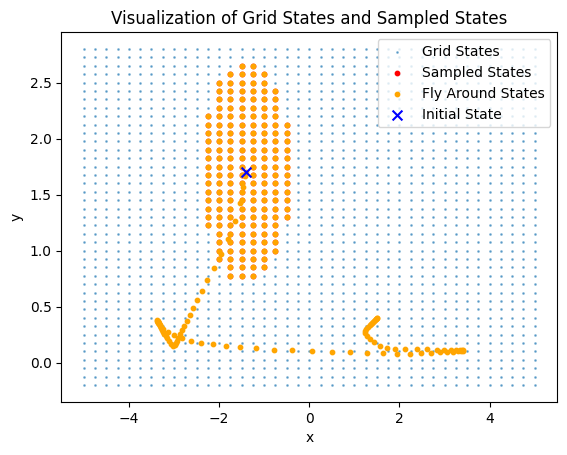

In [21]:
# Visualize all the states that have been sampled - initial states + fly around states (using proximity to grid less than threshold?)
# Visualize the grid of image states and the sampled states within it using the grid states
fig, ax = plt.subplots()
ax.scatter(flattened_img_grid_states[:, 0], flattened_img_grid_states[:, 1], s=1, label="Grid States", alpha=0.5)
sampled_states = flattened_img_grid_states[close_indices]
ax.scatter(sampled_states[:, 0], sampled_states[:, 1], s=10, color='red', label="Sampled States")
ax.scatter(gp_model_partial.X[:, 0], gp_model_partial.X[:, 1], s=10, color='orange', label="Fly Around States")
ax.scatter(init_state[0].item(), init_state[1].item(), s=50, color='blue', label="Initial State", marker='x')
ax.set_title("Visualization of Grid States and Sampled States"

)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()


In [22]:
# Get the new GP predicted image and use as model input
model_input_min = 0.0
model_input_max = 1.0
num_std_away = 2.0

# Get GP predicted image after addition

gp_partial_model_input, gp_predicted_disturbance_image_partial_add, gp_predicted_disturbance_image_partial_add_var = \
                                                gp_model_to_2dinput_image_with_clipping(gp_model_partial, grid_states, 
                                                                        vmin=model_input_min, 
                                                                        vmax=model_input_max,
                                                                        num_std_away=num_std_away)


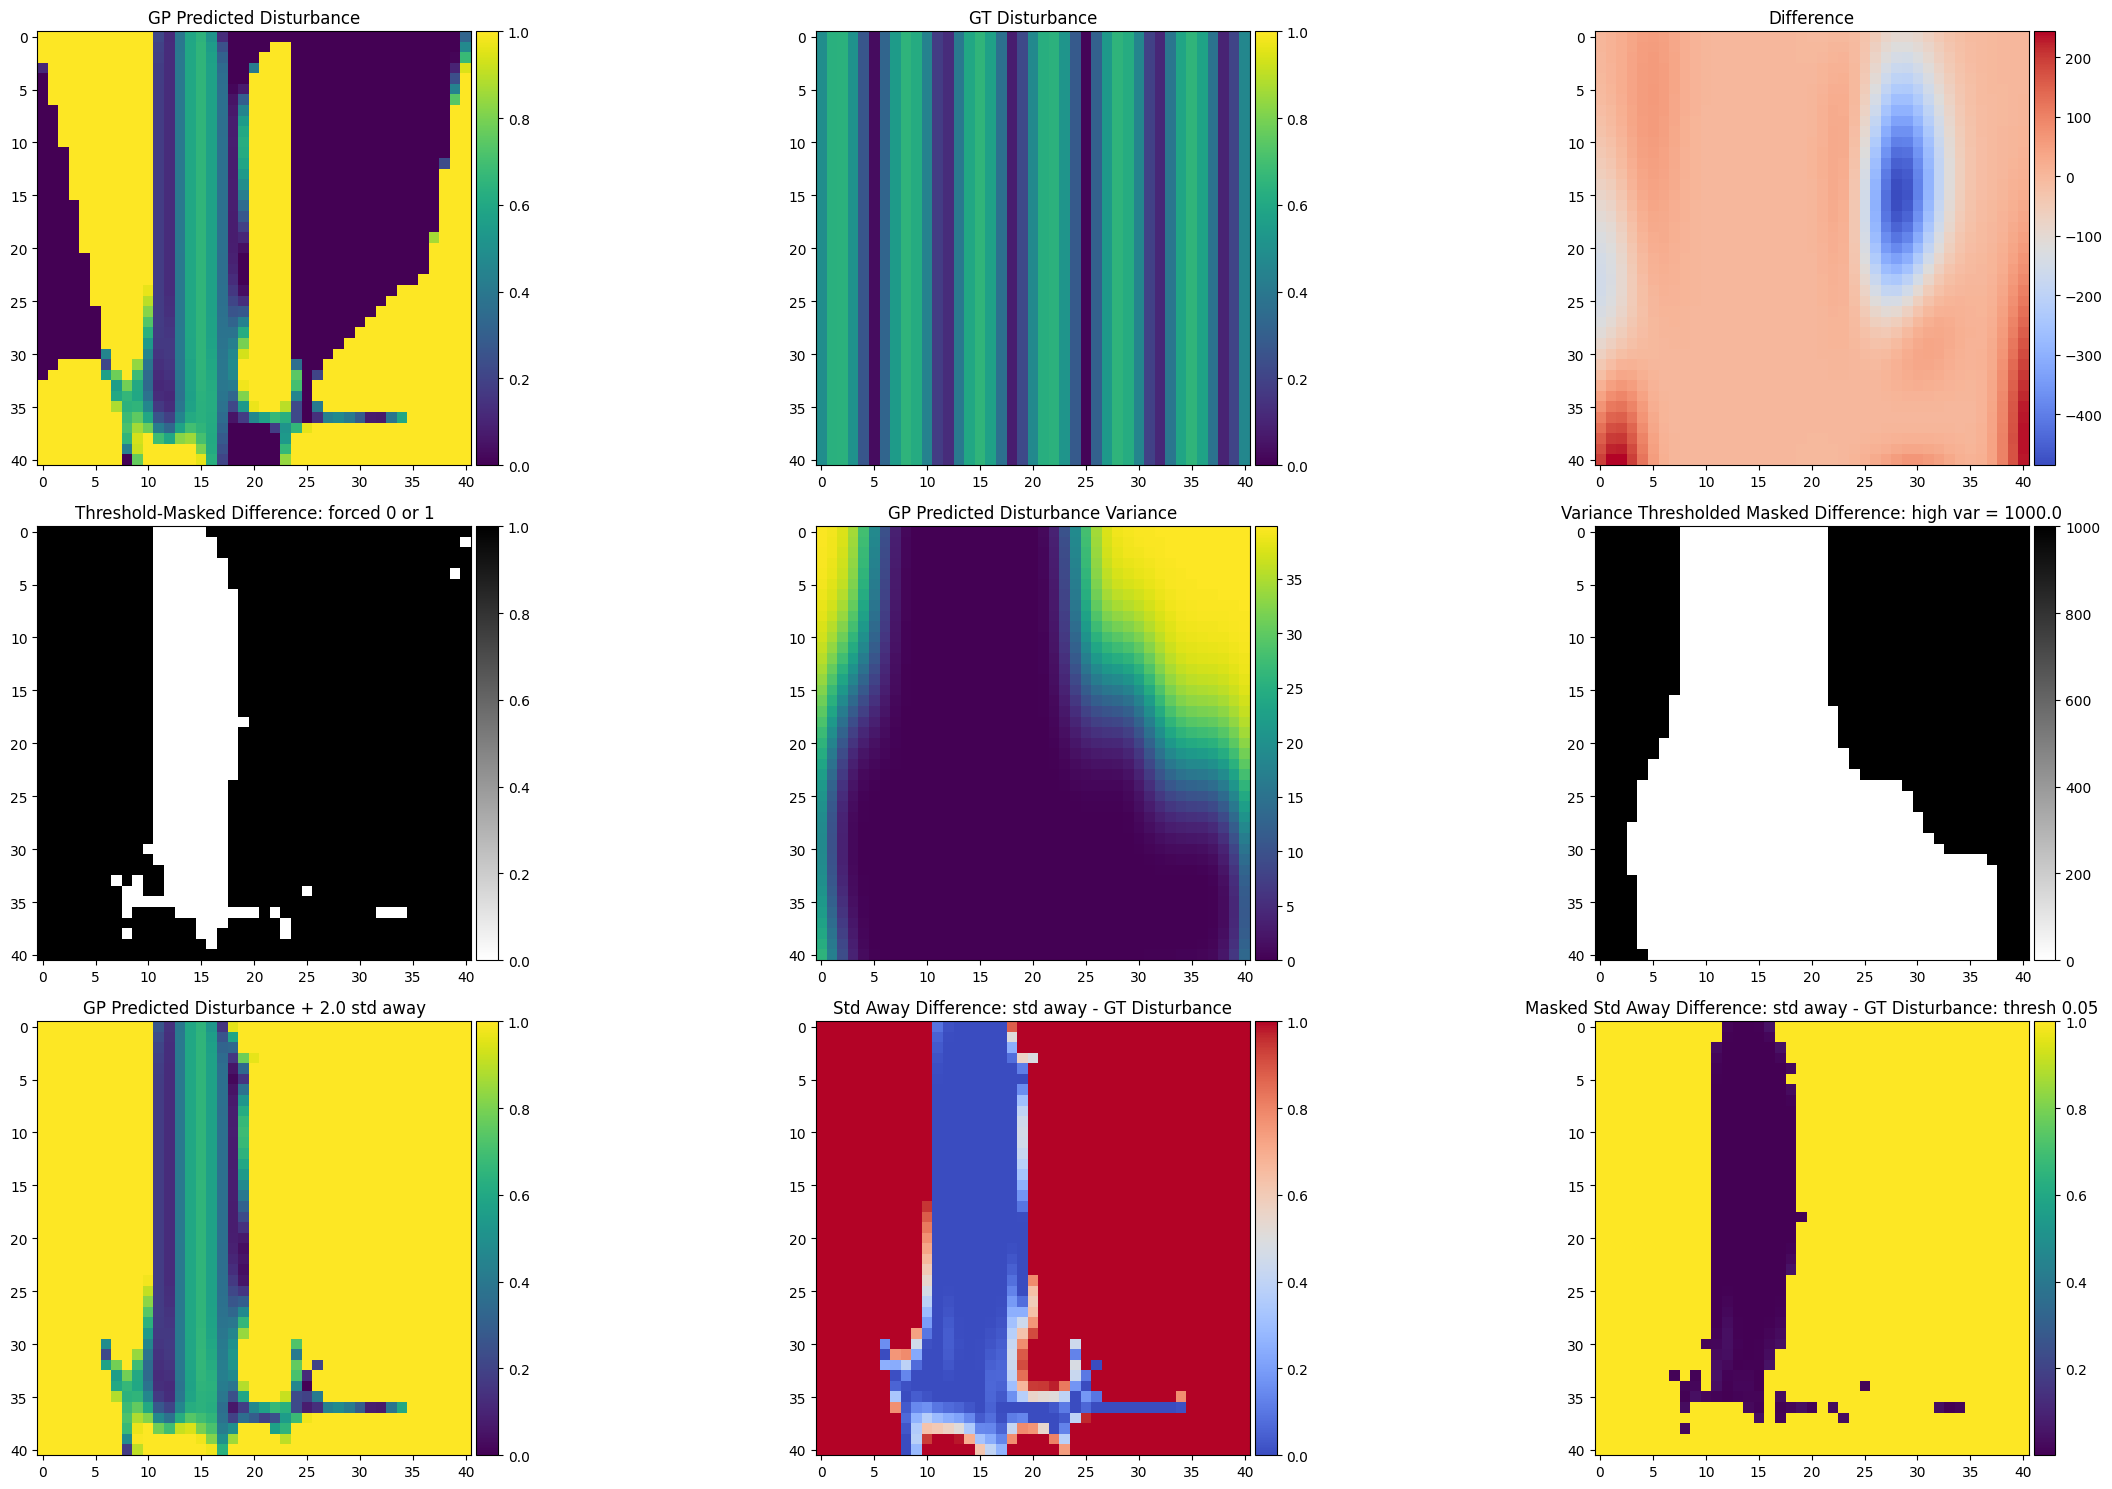

In [23]:
diff_threshold = 0.05
var_threshold = 1.0

plot_gp_predicted_disturbance_image(loaded_input, gp_predicted_disturbance_image_partial_add, gp_predicted_disturbance_image_partial_add_var, 
                                        diff_threshold, var_threshold)

In [43]:
# Get learned value function from Partial GP Image 
device = "cpu" #"cuda:0"

grid_states_torch = torch.from_numpy(grid_states).to(device).float()
grid_value_function_partial, channel_dim_partial, flattened_tensor_dataset_partial  = get_gridvalue_function_from_model(
    disturbance_input=torch.from_numpy(gp_partial_model_input[:, :, 0]).to(device).float(), 
    grid_states=np.array(grid_states), 
    model=model.to(device), 
    data_processor=data_processor, 
    device=device)

learned_value_function_partial = grid_value_function_partial

 /home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/fly_around.py:83: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
 /home/jingpei/anaconda3/envs/neuraloperator_deepreach/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning:os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
 /home/jingpei/anaconda3/envs/neuraloperator_deepreach/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning:os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


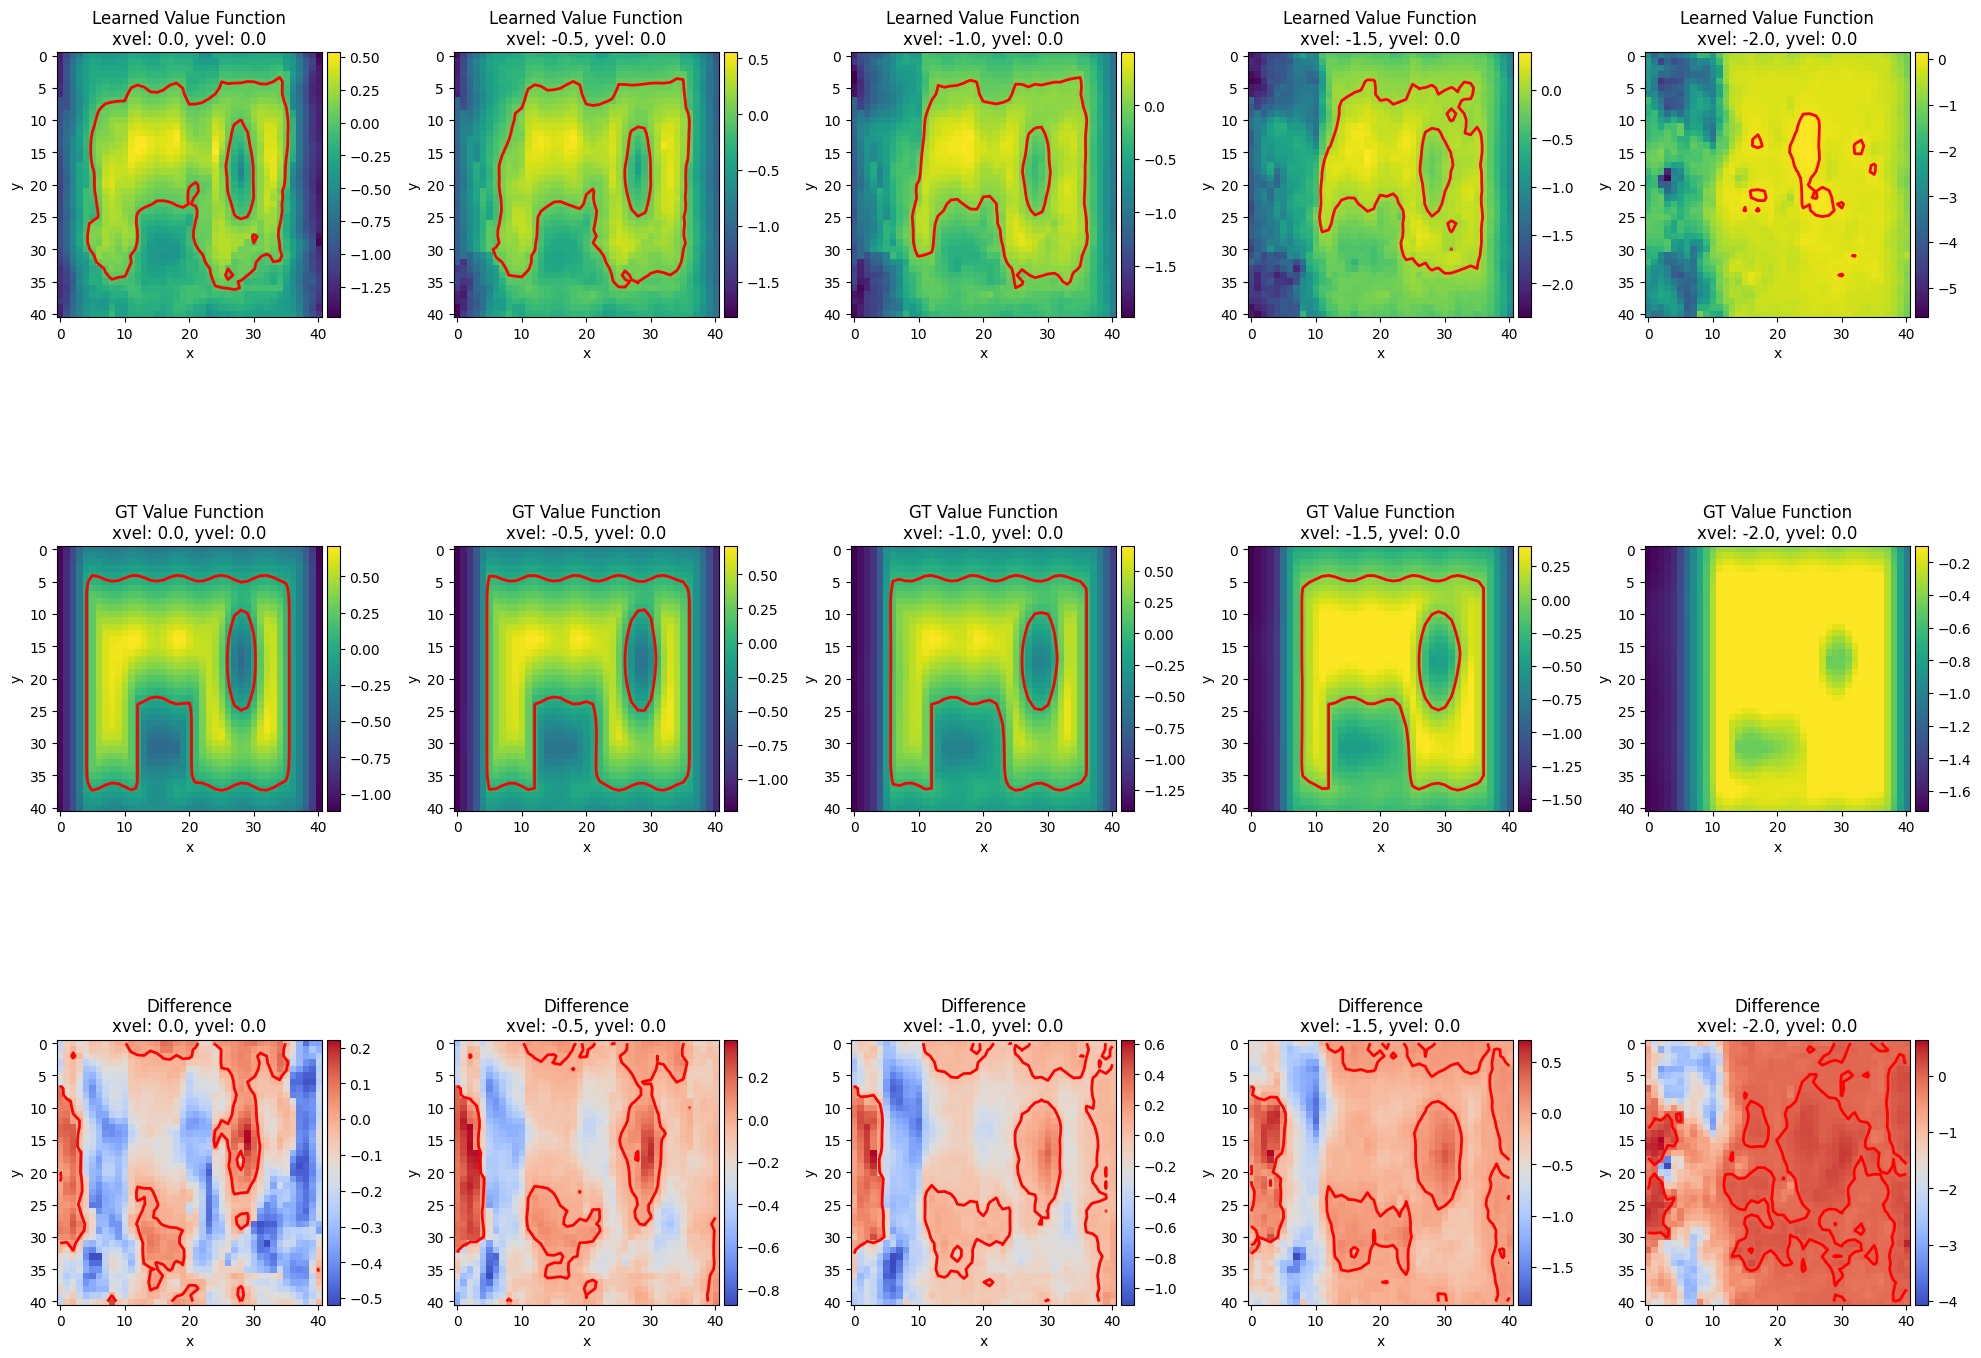

In [44]:
# Visualize 
# NOTE: for now just visualize against the full GT - later generate partial GT value
plot_value_functions_comparison(learned_value_function_partial, gt_value_function=loaded_output, xvel_slices = [20, 15, 10, 5, 0], yvel_slices=[20])

# HJR Partial solution

In [24]:
# Get HJR solution with the new partial disturbance function
min_disturbance_magnitude = 0.0
max_disturbance_magnitude = 1.0
num_std_away = 2.0

num_time_steps = 5
grid_resolution = (41, 41, 21, 21) #(41, 41, 41, 41) #grid_states.shape[:4] # (41, 41, 41, 41)
print("Grid resolution: ", grid_resolution)

partial_gp_disturbance_fn_for_hjr = get_disturbance_fn_from_GP_jax_USEGRID(gp_model=gp_model_partial, 
                                                                           grid_states=grid_states[:, :, 0, 0,:], 
                                                                min_disturbance_magnitude=min_disturbance_magnitude, 
                                                                max_disturbance_magnitude=max_disturbance_magnitude, 
                                                                num_std_away=num_std_away)

############# DEBUG #############
# og_disturbancce_fn = get_disturbance_function_sincos(max_magnitude=1.0, 
#                                            phase_multiplier=1.0,
#                                            phase_shift=0.0, 
#                                            dim='x', 
#                                            use_sin=True,)
# partial_gp_disturbance_fn_for_hjr = og_disturbancce_fn
############# DEBUG #############


dynamics_model_partial_hjr, dynamics_model_partial = get_dynamics_model_given_disturbance_fn(
                                                        disturbance_function=partial_gp_disturbance_fn_for_hjr,
                                                        tMin=tMin,
                                                        tMax=tMax, 
                                                        ret_system=True
                                                    )


# Solve Ground Truth HJR

# # TODO: FINISH THIS PART
ground_truth_hj_solution_partial = GroundTruthHJSolution(
    hj_dynamics=dynamics_model_partial_hjr, 
    solve=True, 
    num_time_steps=num_time_steps, 
    grid_resolution=grid_resolution
)
# ground_truth_hj_solution_partial.grid.states = ground_truth_hj_solution_partial.grid.states.astype(np.float64)
# ground_truth_hj_solution_partial.solve_hjr()  # Solve the HJ solution

gt_value_function_partial = ground_truth_hj_solution_partial.value_functions[-1, :, :, :, :]  # shape grid_resolution - the last time step 

Grid resolution:  (41, 41, 21, 21)


100%|##########|  3.0000/3.0 [00:04<00:00,  1.37s/sim_s]


In [49]:
######## Defining Key Functions ########

def plot_value_functions_comparison_partial(learned_value_function, gt_value_function, xvels_testfn, yvels_testfn, xvels_gtfn, yvels_gtfn, 
                                            xvel_slices_testfn, yvel_slices_testfn, 
                                            xvel_slices_gtfn, yvel_slices_gtfn):
    """
    Function to plot comparison between value functions when the slices of both don't correspond (computed at different resolutions). 
    Args:
        - learned_value_function: The value function computed by the dynamics model (shape: [num_time_steps, grid_size_x, grid_size_y, xvels, yvels])
        - gt_value_function: The ground truth value function (shape: [num_time_steps, grid_size_x, grid_size_y, xvels, yvels])
        - xvels_testfn: The x velocities for the learned value function
        - yvels_testfn: The y velocities for the learned value function
        - xvels_gtfn: The x velocities for the ground truth value function
        - yvels_gtfn: The y velocities for the ground truth value function
        - xvel_slices_testfn: The slices of x velocities for the learned value function
        - yvel_slices_testfn: The slices of y velocities for the learned value function
        - xvel_slices_gtfn: The slices of x velocities for the ground truth value function
        - yvel_slices_gtfn: The slices of y velocities for the ground truth value function
    """
    
    assert(len(xvel_slices_testfn) == len(xvel_slices_gtfn)), "xvel slices for test and gt value functions must be the same length"
    assert(len(yvel_slices_testfn) == len(yvel_slices_gtfn)), "yvel slices for test and gt value functions must be the same length"
    for yvel_slice_num in range(len(yvel_slices_testfn)): 
        # Visualize True Value Function
        fig, axes = plt.subplots(3, len(xvel_slices_testfn), figsize=(20, 15))

        for xvel_slice_num in range(len((xvel_slices_testfn))):
            xvel_slice_testfn = xvel_slices_testfn[xvel_slice_num]
            yvel_slice_testfn = yvel_slices_testfn[yvel_slice_num]
            xvel_slice_gtfn = xvel_slices_gtfn[xvel_slice_num]
            yvel_slice_gtfn = yvel_slices_gtfn[yvel_slice_num]
            
            xvel_testfn = xvels_testfn[xvel_slice_testfn]
            yvel_testfn = yvels_testfn[yvel_slice_testfn]
            xvel_gtfn = xvels_gtfn[xvel_slice_gtfn]
            yvel_gtfn = yvels_gtfn[yvel_slice_gtfn]

            # Learned Value Function
            curr_value_function = learned_value_function[:, :, xvel_slice_testfn, yvel_slice_testfn]
            im0 = axes[0, xvel_slice_num].imshow(np.rot90(curr_value_function), cmap='viridis', interpolation='nearest')
            axes[0, xvel_slice_num].contour(np.rot90(curr_value_function), levels=[0], colors='red', linewidths=2)
            axes[0, xvel_slice_num].set_title(f"Learned Value Function\nxvel: {xvel_testfn:.3f}, yvel: {yvel_testfn:.3f}")
            axes[0, xvel_slice_num].set_xlabel("x")
            axes[0, xvel_slice_num].set_ylabel("y")
            divider0 = make_axes_locatable(axes[0, xvel_slice_num])
            cax0 = divider0.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im0, cax=cax0)

            # Ground Truth Value Function
            # gt_value_function = loaded_output[:, :, xvel_slice, yvel_slice]
            gt_value_function_slice = gt_value_function[:, :, xvel_slice_gtfn, yvel_slice_gtfn]
            im1 = axes[1, xvel_slice_num].imshow(np.rot90(gt_value_function_slice), cmap='viridis', interpolation='nearest')
            axes[1, xvel_slice_num].contour(np.rot90(gt_value_function_slice), levels=[0], colors='red', linewidths=2)
            axes[1, xvel_slice_num].set_title(f"GT Value Function\nxvel: {xvel_gtfn:.3f}, yvel: {yvel_gtfn:.3f}")
            axes[1, xvel_slice_num].set_xlabel("x")
            axes[1, xvel_slice_num].set_ylabel("y")
            divider1 = make_axes_locatable(axes[1, xvel_slice_num])
            cax1 = divider1.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im1, cax=cax1)

            # Difference
            difference = curr_value_function - gt_value_function_slice
            im2 = axes[2, xvel_slice_num].imshow(np.rot90(difference), cmap='coolwarm', interpolation='nearest')
            axes[2, xvel_slice_num].contour(np.rot90(difference), levels=[0], colors='red', linewidths=2)
            axes[2, xvel_slice_num].set_title(f"Difference\nxvel: {xvel_testfn:.3f}, yvel: {yvel_testfn:.3f}")
            axes[2, xvel_slice_num].set_xlabel("x")
            axes[2, xvel_slice_num].set_ylabel("y")
            divider2 = make_axes_locatable(axes[2, xvel_slice_num])
            cax2 = divider2.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im2, cax=cax2)

        plt.tight_layout()
        plt.show()

def find_corresponding_indices(xvels, partial_xvels, tolerance=1e-5):
    """
    Finds the indices where the values of two lists correspond within a given tolerance.

    Args:
        xvels (list or numpy.ndarray): The first list of values.
        partial_xvels (list or numpy.ndarray): The second list of values.
        tolerance (float): The tolerance within which values are considered corresponding.

    Returns:
        list: A list of tuples where each tuple contains the index from xvels and the corresponding index from partial_xvels.
    """
    corresponding_indices = []
    for i, xvel in enumerate(xvels):
        for j, partial_xvel in enumerate(partial_xvels):
            if abs(xvel - partial_xvel) <= tolerance:
                corresponding_indices.append((i, j))
    return corresponding_indices

In [50]:
partial_xvels = np.array(ground_truth_hj_solution_partial.grid.states[0, 0, :, 0, 2])
partial_yvels = np.array(ground_truth_hj_solution_partial.grid.states[0, 0, 0, :, 3])

corresponding_indices = find_corresponding_indices(xvels, partial_xvels)
corresponding_indices_yvel = find_corresponding_indices(yvels, partial_yvels)
print("Corresponding indices: ", corresponding_indices)
print("num corsresponding indices: ", len(corresponding_indices))
print("\nCorresponding indices yvel: ", corresponding_indices_yvel)
print("num corsresponding indices yvel: ", len(corresponding_indices_yvel))

corresponding_indices_touse = [2, 5, 10, 15, 18]  #[0, 5, 10, 15, 20]  
corresponding_indices_touse_yvel = [10]
xvel_slices_partialcomp = [corresponding_indices[i][0] for i in corresponding_indices_touse]
partial_xvel_slices_partialcomp = [corresponding_indices[i][1] for i in corresponding_indices_touse]
yvel_slices_partialcomp = [corresponding_indices_yvel[i][0] for i in corresponding_indices_touse_yvel]
partial_yvel_slices_partialcomp = [corresponding_indices_yvel[i][1] for i in corresponding_indices_touse_yvel]

print("\nxvel slices: ", xvel_slices_partialcomp)
print("partial xvel slices: ", partial_xvel_slices_partialcomp)
print("\nxvels: ", xvels[xvel_slices_partialcomp])
print("partial xvels: ", partial_xvels[partial_xvel_slices_partialcomp])

print("\nyvel slices: ", yvel_slices_partialcomp)
print("partial yvel slices: ", partial_yvel_slices_partialcomp)
print("\nyvels: ", yvels[yvel_slices_partialcomp])
print("partial yvels: ", partial_yvels[partial_yvel_slices_partialcomp])


Corresponding indices:  [(0, 0), (2, 1), (4, 2), (6, 3), (8, 4), (10, 5), (12, 6), (14, 7), (16, 8), (18, 9), (20, 10), (22, 11), (24, 12), (26, 13), (28, 14), (30, 15), (32, 16), (34, 17), (36, 18), (38, 19), (40, 20)]
num corsresponding indices:  21

Corresponding indices yvel:  [(0, 0), (2, 1), (4, 2), (6, 3), (8, 4), (10, 5), (12, 6), (14, 7), (16, 8), (18, 9), (20, 10), (22, 11), (24, 12), (26, 13), (28, 14), (30, 15), (32, 16), (34, 17), (36, 18), (38, 19), (40, 20)]
num corsresponding indices yvel:  21

xvel slices:  [4, 10, 20, 30, 36]
partial xvel slices:  [2, 5, 10, 15, 18]

xvels:  [-1.5999999 -1.         0.         1.         1.6000001]
partial xvels:  [-1.5999999 -1.         0.         1.         1.6000001]

yvel slices:  [20]
partial yvel slices:  [10]

yvels:  [0.]
partial yvels:  [0.]


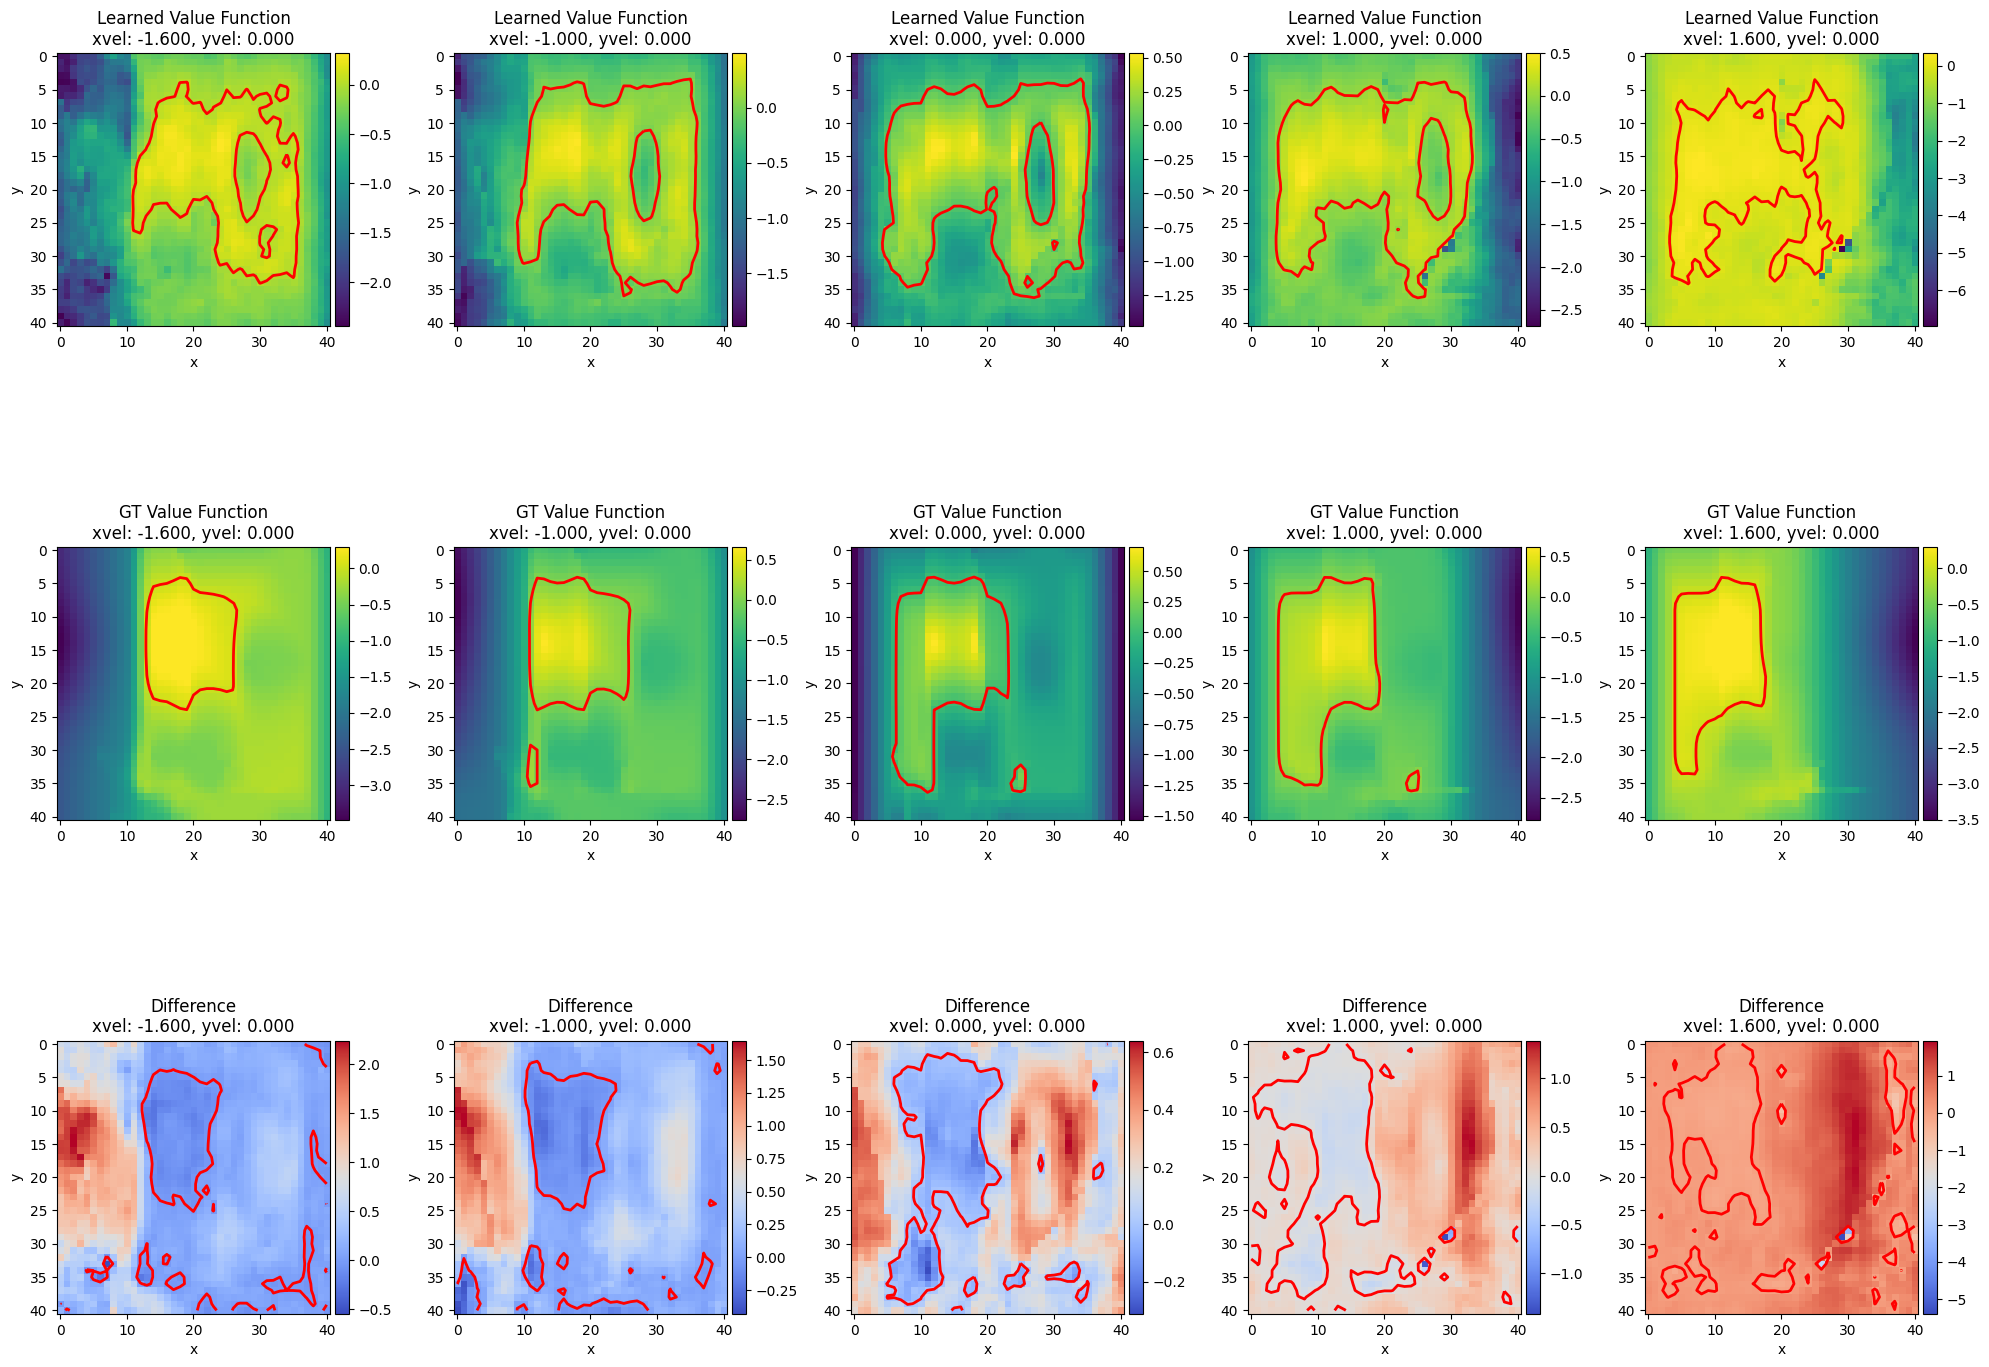

In [51]:
plot_value_functions_comparison_partial(learned_value_function=learned_value_function_partial, 
                                        gt_value_function=np.array(gt_value_function_partial), 
                                        xvels_testfn=xvels, 
                                        yvels_testfn=yvels, 
                                        xvels_gtfn=partial_xvels, 
                                        yvels_gtfn=partial_yvels, 
                                        xvel_slices_testfn=xvel_slices_partialcomp, yvel_slices_testfn=yvel_slices_partialcomp, 
                                        xvel_slices_gtfn=partial_xvel_slices_partialcomp, yvel_slices_gtfn=partial_yvel_slices_partialcomp)

# OLD DEBUGGING CODE

# DEBUGGING BELOW

In [30]:
partial_xvels = ground_truth_hj_solution_partial.grid.states[0, 0, :, 0, 2]
partial_yvels = ground_truth_hj_solution_partial.grid.states[0, 0, 0, :, 3]
print("partial_xvels", partial_xvels)
print("partial_yvels", partial_yvels)

xvels = grid_states[0, 0, :, 0, 2]
yvels = grid_states[0, 0, 0, :, 3]

print("\nxvels", xvels)
print("yvels", yvels)

xvel_slices = [20, 15, 10, 5, 0]
yvel_slices = [20]
print("\nxvels", xvels[xvel_slices])
print("yvels", yvels[yvel_slices])

corresponding_xvel_slices = []
corresponding_xvels = []
for xvel_slice_idx in xvel_slices: 
    for partial_xvel_slice_idx in range(len(partial_xvels)):
        if np.isclose(partial_xvels[partial_xvel_slice_idx], xvels[xvel_slice_idx], atol=1e-5):
            corresponding_xvel_slices.append(partial_xvel_slice_idx)
            corresponding_xvels.append(partial_xvels[partial_xvel_slice_idx])

corresponding_yvel_slices = []
corresponding_yvels = []
for yvel_slice_idx in yvel_slices: 
    for partial_yvel_slice_idx in range(len(partial_yvels)):
        if np.isclose(partial_yvels[partial_yvel_slice_idx], yvels[yvel_slice_idx], atol=1e-5):
            corresponding_yvel_slices.append(partial_yvel_slice_idx)
            corresponding_yvels.append(partial_yvels[partial_yvel_slice_idx])

print(corresponding_xvel_slices)
print(corresponding_yvel_slices)
print("\n")
print(corresponding_xvels)
print(corresponding_yvels)

partial_xvels [-2.         -1.8        -1.5999999  -1.4000001  -1.2        -1.
 -0.79999995 -0.59999996 -0.40000004 -0.19999987  0.          0.20000005
  0.4000001   0.60000014  0.79999995  1.          1.2         1.4000001
  1.6000001   1.8         2.        ]
partial_yvels [-2.         -1.8        -1.5999999  -1.4000001  -1.2        -1.
 -0.79999995 -0.59999996 -0.40000004 -0.19999987  0.          0.20000005
  0.4000001   0.60000014  0.79999995  1.          1.2         1.4000001
  1.6000001   1.8         2.        ]

xvels [-2.         -1.9000001  -1.8        -1.7        -1.5999999  -1.5
 -1.4000001  -1.3        -1.2        -1.0999999  -1.         -0.90000004
 -0.79999995 -0.69999987 -0.59999996 -0.5        -0.40000004 -0.29999995
 -0.19999987 -0.09999996  0.          0.10000014  0.20000005  0.29999995
  0.4000001   0.5         0.60000014  0.70000005  0.79999995  0.9000001
  1.          1.1000001   1.2         1.3         1.4000001   1.5
  1.6000001   1.7         1.8         1.900000

In [ ]:
# IMPORTANT TODO: TO GET GT WORKING

# 1. Write GPy predict function using jax 
# 2. change hte get_disturbance_fn_from_GP to use purely jax when input is jax array 
# 3. re-runabove code 1

# Jusst debugging for a bit

In [ ]:
def get_disturbance_fn_from_GP_chunked(gp_model, min_disturbance_magnitude, max_disturbance_magnitude,
                                num_std_away=2.0, max_chunk_size=512):
    """
    Converts a GP model to a disturbance function usable in a dynamics model,
    with chunked input processing to reduce memory load.

    gp_model:
        - Must have methods: predict() for NumPy/Torch, and predict_jax() for JAX
    """
    def disturbance_function(state):
        is_torch_tensor = False

        if isinstance(state, (torch.Tensor, np.ndarray)):
            if isinstance(state, torch.Tensor):
                is_torch_tensor = True
                if len(state.shape) == 1:
                    state = state.unsqueeze(0)
                state = state.cpu().numpy()
            elif isinstance(state, np.ndarray):
                if len(state.shape) == 1:
                    state = np.expand_dims(state, axis=0)
                state = np.array(state, dtype=np.float32)

            # Chunk the input
            total_states = state.shape[0]
            results = []

            for i in range(0, total_states, max_chunk_size):
                chunk = state[i:i + max_chunk_size]
                means, vars = gp_model.predict(chunk[:, :2])
                chunk_disturb = np.abs(means) + num_std_away * np.sqrt(vars)
                chunk_disturb = np.clip(chunk_disturb, min_disturbance_magnitude, max_disturbance_magnitude)
                chunk_disturb = np.tile(chunk_disturb, (1, 4))
                results.append(chunk_disturb)

            disturbances = np.concatenate(results, axis=0)

            if is_torch_tensor:
                disturbances = torch.tensor(disturbances, dtype=torch.float32)
            else:
                disturbances = jax.numpy.array(disturbances)

        elif isinstance(state, (jnp.ndarray, Array)):
            if len(state.shape) == 1:
                state = jnp.expand_dims(state, 0)

            total_states = state.shape[0]
            results = []

            for i in range(0, total_states, max_chunk_size):
                chunk = state[i:i + max_chunk_size]
                means, vars = gp_model.predict_jax(chunk[:, :2])
                chunk_disturb = jnp.abs(means) + num_std_away * jnp.sqrt(vars)
                chunk_disturb = jnp.clip(chunk_disturb, min_disturbance_magnitude, max_disturbance_magnitude)
                chunk_disturb = jnp.tile(chunk_disturb, (1, 4))
                results.append(chunk_disturb)

            disturbances = jnp.concatenate(results, axis=0)

        else:
            raise TypeError(f"Unsupported input type: {type(state)}")

        if disturbances.shape[0] == 1:
            return disturbances[0]
        else:
            return disturbances

    return disturbance_function


In [ ]:
partial_gp_disturbance_fn_for_hjr_og_chunked = get_disturbance_fn_from_GP_chunked(gp_model=gp_model_partial, 
                                                                min_disturbance_magnitude=min_disturbance_magnitude, 
                                                                max_disturbance_magnitude=max_disturbance_magnitude, 
                                                                num_std_away=num_std_away)

partial_gp_disturbance_fn_for_hjr_og = get_disturbance_fn_from_GP(gp_model=gp_model_partial, 
                                                                min_disturbance_magnitude=min_disturbance_magnitude, 
                                                                max_disturbance_magnitude=max_disturbance_magnitude, 
                                                                num_std_away=num_std_away)

partial_gp_disturbance_fn_for_hjr = get_disturbance_fn_from_GP_jax_USEGRID(gp_model=gp_model_partial, 
                                                                           grid_states=grid_states[:, :, 0, 0,:], 
                                                                min_disturbance_magnitude=min_disturbance_magnitude, 
                                                                max_disturbance_magnitude=max_disturbance_magnitude, 
                                                                num_std_away=num_std_away)

og_disturbancce_fn = get_disturbance_function_sincos(max_magnitude=1.0, 
                                           phase_multiplier=1.0,
                                           phase_shift=0.0, 
                                           dim='x', 
                                           use_sin=True,)


state_inputs = flattened_img_grid_states  # [x, y, xvel, yvel]
state_inputs = torch.tensor(flattened_img_grid_states)  # [x, y, xvel, yvel]
print("State inputs type: ", type(state_inputs))

partial_gp_out_og_chunked = partial_gp_disturbance_fn_for_hjr_og_chunked(state_inputs)
partial_gp_out_og = partial_gp_disturbance_fn_for_hjr_og(state_inputs)
partial_gp_out = partial_gp_disturbance_fn_for_hjr(state_inputs)
og_dist_out = og_disturbancce_fn(state_inputs)

In [ ]:
import math 
np.isnan(partial_gp_out_og).any()

In [ ]:
print("Partial GP Disturbance Output (OG): ", partial_gp_out_og.shape)
print("Partial GP Disturbance Output (OG Chunked): ", partial_gp_out_og_chunked.shape)
print("Partial GP Disturbance Output: ", partial_gp_out.shape)
print("OG Disturbance Output: ", og_dist_out.shape)

print("\n")
print("Type of Partial GP Disturbance Output (OG): ", type(partial_gp_out_og))
print("Type of Partial GP Disturbance Output (OG Chunked): ", type(partial_gp_out_og_chunked))
print("Type of Partial GP Disturbance Output: ", type(partial_gp_out))
print("Type of OG Disturbance Output: ", type(og_dist_out))

print("\n")
# Convert all outputs to numpy arrays before calculating differences
partial_gp_out_og_np = np.array(partial_gp_out_og)
partial_gp_out_og_chunked_np = np.array(partial_gp_out_og_chunked)
partial_gp_out_np = np.array(partial_gp_out)
og_dist_out_np = np.array(og_dist_out)

print("Sum of absolute differences (OG): ", np.sum(np.abs(partial_gp_out_og_np - partial_gp_out_np)))
print("Sum of absolute differences (OG Chunked): ", np.sum(np.abs(partial_gp_out_og_chunked_np - partial_gp_out_np)))
print("Sum of absolute differences (OG Disturbance): ", np.sum(np.abs(og_dist_out_np - partial_gp_out_np)))

In [ ]:
partial_gp_disturbance_fn_for_hjr = get_disturbance_fn_from_GP(gp_model=gp_model_partial, 
                                                                min_disturbance_magnitude=min_disturbance_magnitude, 
                                                                max_disturbance_magnitude=max_disturbance_magnitude, 
                                                                num_std_away=num_std_away)

image_grid_states = grid_states[:, :, 0, 0, :]  # [x, y, xvel, yvel]
partial_gp_disturbance_fn_for_hjr_grid = get_disturbance_fn_from_GP_jax_USEGRID(gp_model=gp_model_partial, 
                                                                                grid_states=image_grid_states, 
                                                                min_disturbance_magnitude=min_disturbance_magnitude, 
                                                                max_disturbance_magnitude=max_disturbance_magnitude, 
                                                                num_std_away=num_std_away)


In [ ]:
flattened_image_grid_states = image_grid_states.reshape(-1, image_grid_states.shape[-1])  # Flatten to [N, 4]
print("Flattened image grid states shape: ", flattened_image_grid_states.shape)
gp_of_partial = partial_gp_disturbance_fn_for_hjr(state=flattened_image_grid_states)
gp_of_partial_grid = partial_gp_disturbance_fn_for_hjr_grid(state=image_grid_states)

recon_gp_of_partial = gp_of_partial.reshape(image_grid_states.shape[0], image_grid_states.shape[1], -1)
recon_gp_of_partial_grid = gp_of_partial_grid.reshape(image_grid_states.shape[0], image_grid_states.shape[1], -1)
print(recon_gp_of_partial.shape)

In [ ]:
# Internal function implementation: 
flattened_grid_states = grid_states[:, :, 0, 0, :].reshape(-1, grid_states.shape[-1])[:, :2]  # Flatten to [N, 4]
disturbances_mean, disturbances_var = gp_model_partial.predict(flattened_grid_states[:, :2])
disturbances = np.abs(disturbances_mean) + num_std_away * np.sqrt(disturbances_var)  # Get max disturbance magnitude
disturbances = np.clip(disturbances, min_disturbance_magnitude, max_disturbance_magnitude)

In [ ]:


state = deepcopy(flattened_grid_states) #[:1000])
print("State shape: ", state.shape)
print("flattened_grid_states shape: ", flattened_grid_states.shape)
print("Difference shape: ", (flattened_grid_states[:, None, :2] - state[:, :2]).shape)

distances = np.linalg.norm(flattened_grid_states[:, None, :2] - state[:, :2], axis=-1)
closest_grid_indices = np.argmin(distances, axis=0)
mag = disturbances[closest_grid_indices]

print("Distances shape: ", distances.shape)
print(mag.shape)

gp_mag = partial_gp_disturbance_fn_for_hjr(state=state)

recon_mag = mag.reshape(image_grid_states.shape[0], image_grid_states.shape[1], -1)
recon_gp_mag = gp_mag.reshape(image_grid_states.shape[0], image_grid_states.shape[1], -1)

# Plot recon_mag, recon_gp_mag, and their difference
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot recon_mag
im0 = axes[0].imshow(np.rot90(recon_mag[:, :, 0]), cmap='viridis', interpolation='nearest')
axes[0].set_title("Recon Mag")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0])

# Plot recon_gp_mag
im1 = axes[1].imshow(np.rot90(recon_gp_mag[:, :, 0]), cmap='viridis', interpolation='nearest')
axes[1].set_title("Recon GP Mag")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1])

# Plot the difference
difference = recon_mag[:, :, 0] - recon_gp_mag[:, :, 0]
im2 = axes[2].imshow(np.rot90(difference), cmap='coolwarm', interpolation='nearest')
axes[2].set_title("Difference")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()


In [ ]:
print("X train jax: ", type(gp_model_partial.X_train_jax))
print("Y train jax: ", type(gp_model_partial.Y_train_jax))
print("alpha jax: ", type(gp_model_partial.alpha_jax))
print("K inv jax: ", type(gp_model_partial.K_inv_jax))

In [ ]:


jax_input = jnp.array([[0, 0]])
numpy_input = np.array([[0, 0]])

jax_input2 = jnp.array([[0.5, 0.5]])
numpy_input2 = np.array([[0.5, 0.5]])

print("jax kernel: ", gp_model_partial.rbf_kernel_jax(jax_input, jax_input2))
print("numpy kernel: ", gp_model_partial.model.kern.K(numpy_input, numpy_input2))

jax_kxtest = gp_model_partial.rbf_kernel_jax(jax_input, gp_model_partial.X_train_jax)
numpy_kxtest = gp_model_partial.model.kern.K(numpy_input, gp_model_partial.X_train_jax)
diff_kxtest = np.array(jax_kxtest) - numpy_kxtest
print("diff kxtest: ", np.sum(np.abs(diff_kxtest)))


print("kxtest is close: ", np.allclose(np.array(jax_kxtest), numpy_kxtest, atol=1e-6))
print("alpha jax is close: ", np.allclose(np.array(gp_model_partial.alpha_jax), np.array(gp_model_partial.model.posterior.woodbury_vector), atol=1e-6))

print("\n\njax kxtest shape: ", jax_kxtest.shape)
print("numpy kxtest shape: ", numpy_kxtest.shape)
print("jax alpha shape: ", gp_model_partial.alpha_jax.shape)
print("numpy alpha shape: ", gp_model_partial.model.posterior.woodbury_vector.shape)
print("\n\n")

print("jax_kxtest dtype:", jnp.array(numpy_kxtest).dtype)
print("woodbury_vector dtype:", jnp.asarray(gp_model_partial.model.posterior.woodbury_vector).dtype)

woodbury_np = gp_model_partial.model.posterior.woodbury_vector
woodbury_jax = jnp.asarray(woodbury_np)


print("woodbury np type: ", woodbury_np.dtype)
print("Max diff woodbury:", np.max(np.abs(woodbury_np - np.array(woodbury_jax))))
print("Mean diff woodbury:", np.mean(np.abs(woodbury_np - np.array(woodbury_jax))))



jax_devices = jax.devices()
device = jax_devices[0] if jax_devices else "cpu"
mean_manual_jax = jnp.dot(jax.device_put(jnp.array(numpy_kxtest), device), jax.device_put(jnp.asarray(gp_model_partial.model.posterior.woodbury_vector), device)) 
mean_manual_numpy = np.dot(numpy_kxtest, gp_model_partial.model.posterior.woodbury_vector) 
diff_mean_manual = np.array(mean_manual_jax) - mean_manual_numpy
print("mean manual jax: ", mean_manual_jax)
print("mean manual numpy: ", mean_manual_numpy)
print("diff mean manual: ", np.sum(np.abs(diff_mean_manual)))


print("jax: ", gp_model_partial.predict_jax(jax_input))
print("numpy: ", gp_model_partial.predict(numpy_input))

In [ ]:
# jax vs. numpy comparison
image_grid = grid_states[:, :, 0, 0, :][:, :, model_input_indices]  # [x, y, 2]
flattened_image_grid = image_grid.reshape(-1, image_grid.shape[-1])[:, :2]  # Flatten to [N, 2]
jax_input = jnp.array(flattened_image_grid, dtype=jnp.float32)
numpy_input = np.array(flattened_image_grid, dtype=np.float32)

jax_mean, jax_var = gp_model_partial.predict_jax(jax_input)
numpy_mean, numpy_var = gp_model_partial.predict(numpy_input)

diff_mean = jax_mean - numpy_mean
diff_var = jax_var - numpy_var


print("diff mean: ", diff_mean)
print("diff var: ", diff_var)

In [ ]:
partial_gp_disturbance_fn_for_hjr = get_disturbance_fn_from_GP(gp_model=gp_model_partial, 
                                                                min_disturbance_magnitude=min_disturbance_magnitude, 
                                                                max_disturbance_magnitude=max_disturbance_magnitude, 
                                                                num_std_away=num_std_away)

thingy = lambda x: gp_model_partial.predict(x)[0] + num_std_away * np.sqrt(gp_model_partial.predict(x)[1])

In [ ]:
mage_grid = grid_states[:, :, 0, 0, :][:, :, model_input_indices]  # [x, y, 2]
flattened_image_grid = image_grid.reshape(-1, image_grid.shape[-1])[:, :2]  # Flatten to [N, 2]
print(flattened_image_grid.shape)

output = gp_model_partial.predict_jax(jnp.asarray(flattened_image_grid))  # [N, 2]
created_output = jnp.clip(output[0] + 2 * output[1], min=0.0, max=1.0)
other_output = partial_gp_disturbance_fn_for_hjr(jnp.asarray(flattened_image_grid))  # [N, 4]

diff = created_output - other_output[:, 0]

print("Output: ", output)
print("Created output: ", created_output)
print("Other output: ", other_output)

print("Difference: ", jnp.sum(jnp.abs(diff)))

In [ ]:
print("jax version: ", partial_gp_disturbance_fn_for_hjr(state=jnp.array([[-1.4, 1.7, 0.0, 0.0]])))  # Should return a disturbance value for the state
print("gpy version: ", thingy(np.array([[-1.4, 1.7]])))  # Should return a disturbance value for the state


# OLD OLD OLD
